# Entrenar el modelo con los datos meteorológicos completos, los epidemiológicos (casos de dengue) sin los rezagos (Este script los calcula) y sin escalado


  PASO 5: OPTIMIZACIÓN EN ESCALA REAL CON SAMPLE WEIGHTS PARA PICOS 
[INFO] Optimización completada. Mejor MAE en CV: 16.79


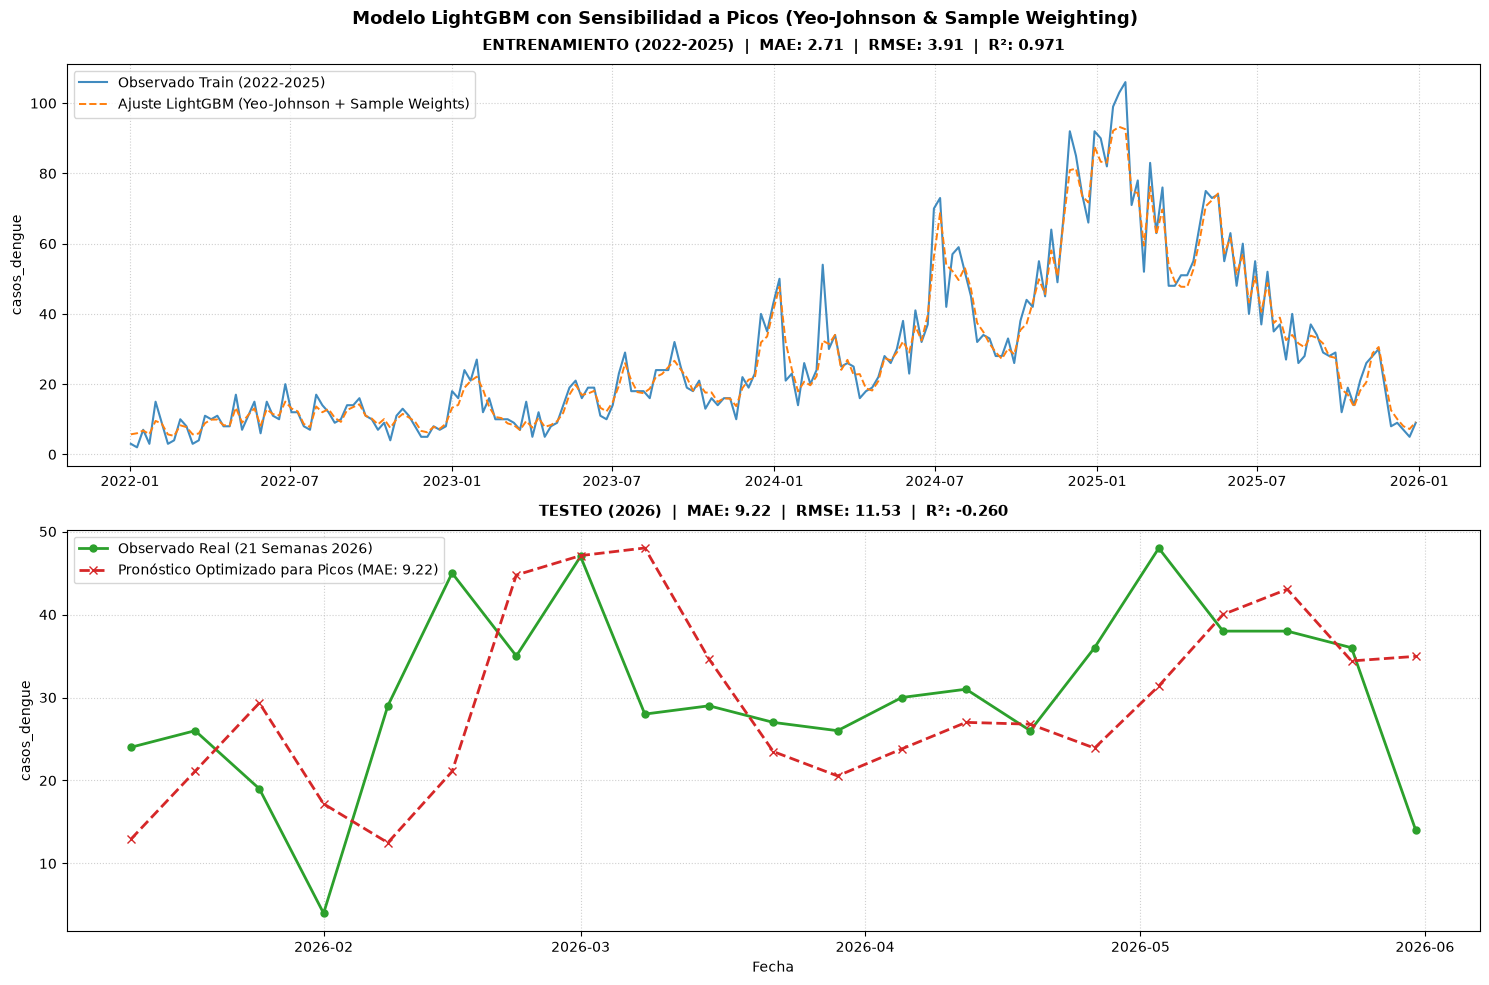


     DESEMPEÑO DEL MODELO SENSIBLE A PICOS Y REZAGOS BIOCLIMÁTICOS     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 2.708863  3.910556  0.970859
 Testeo (21 Semanas 2026)       21 9.222781 11.526765 -0.260087


In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PowerTransformer
import lightgbm as lgb
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE CARACTERÍSTICAS PARA CAPTURA DE PICOS Y BIOCLIMA EXTENDIDO
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# Rezagos epidemiológicos adicionales de alta sensibilidad
df['casos_lag_3'] = df['casos_dengue'].shift(3)
df['casos_lag_4'] = df['casos_dengue'].shift(4)

# Dinámicas de aceleración y cambio de velocidad
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)
df['ewma_2w'] = df[col_lag1].ewm(span=2, adjust=False).mean()
df['ewma_4w'] = df[col_lag1].ewm(span=4, adjust=False).mean()
df['momentum_epidemico'] = df['ewma_2w'] - df['ewma_4w']

# Rezagos bioclimáticos de horizonte extendido (4, 6 y 8 semanas)
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acum_4w'] = df[target_p].shift(2).rolling(window=4, min_periods=1).sum()
    df['lluvia_acum_8w'] = df[target_p].shift(4).rolling(window=8, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_media_6w'] = df[target_t].shift(3).rolling(window=6, min_periods=1).mean()
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

df = df.dropna()

# =============================================================================
# PASO 3: DIVISIÓN DE DATOS Y TRANSFORMADOR YEO-JOHNSON
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)
df_2026 = df[df.index.year >= 2026]
semanas_2026 = len(df_2026)
mask_test = df.index.isin(df_2026.iloc[:semanas_2026].index)

X_raw = df.drop(columns=['casos_dengue'])
y_real = df['casos_dengue']

# Transformación Yeo-Johnson (Preserva la escala de picos sin aplastarla como log1p)
pt = PowerTransformer(method='yeo-johnson', standardize=False)
y_train_trans = pt.fit_transform(y_real[mask_train].values.reshape(-1, 1)).flatten()

X_train_raw = X_raw[mask_train]
y_train_real = y_real[mask_train]

X_test_raw = X_raw[mask_test]
y_test_real = y_real[mask_test]

# Matriz de Ponderación de Muestras (Sample Weights) para obligar al modelo a atinarle a los picos
# Asigna hasta 3.5 veces más importancia a las semanas con brotes epidémicos
max_casos_train = y_train_real.max()
sample_weights_train = 1.0 + 2.5 * (y_train_real.values / max_casos_train) ** 2

# Limpieza de multicolinealidad
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.88
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'ewma_2w', 'momentum_epidemico', 'lluvia_acum_8w'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_raw.drop(columns=to_drop_corr)

# =============================================================================
# PASO 4: PURGED TIME SERIES CV
# =============================================================================
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=4, group_gap=2):
        self.n_splits = n_splits
        self.group_gap = group_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        group_size = n_samples // (self.n_splits + 1)
        
        for i in range(self.n_splits):
            train_end = group_size * (i + 1)
            val_start = train_end + self.group_gap
            val_end = val_start + group_size
            
            if val_end > n_samples:
                break
                
            train_indices = list(range(0, train_end))
            val_indices = list(range(val_start, val_end))
            
            yield train_indices, val_indices

# =============================================================================
# PASO 5: OPTIMIZACIÓN OPTUNA EN ESCALA REAL CON PONDERACIÓN POR BROS
# =============================================================================
print("\n" + "="*80)
print("  PASO 5: OPTIMIZACIÓN EN ESCALA REAL CON SAMPLE WEIGHTS PARA PICOS ")
print("="*80)

def objective_picos(trial):
    params = {
        'objective': trial.suggest_categorical('objective', ['huber', 'regression_l1']),
        'alpha': trial.suggest_float('alpha', 0.8, 2.5) if trial.params.get('objective') == 'huber' else 1.0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=20),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 5),             # Profundidad suficiente para escalar en picos
        'num_leaves': trial.suggest_int('num_leaves', 8, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 4, 15),
        
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 3.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.05, 10.0, log=True),
        
        'random_state': 42,
        'verbosity': -1
    }

    cv = PurgedGroupTimeSeriesSplit(n_splits=4, group_gap=2)
    maes_cv = []

    for train_idx, val_idx in cv.split(X_train_clean):
        X_tr, y_tr_trans = X_train_clean.iloc[train_idx], y_train_trans[train_idx]
        w_tr = sample_weights_train[train_idx]
        
        X_va = X_train_clean.iloc[val_idx]
        y_va_real = y_train_real.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_trans, sample_weight=w_tr)

        pred_va_trans = model.predict(X_va)
        pred_va_real = pt.inverse_transform(pred_va_trans.reshape(-1, 1)).flatten()
        
        mae_fold = mean_absolute_error(y_va_real, pred_va_real)
        maes_cv.append(mae_fold)

    return np.mean(maes_cv)

study = optuna.create_study(direction='minimize')
study.optimize(objective_picos, n_trials=70, show_progress_bar=False)

print(f"[INFO] Optimización completada. Mejor MAE en CV: {study.best_value:.2f}")

# =============================================================================
# PASO 6: ENTRENAMIENTO FINAL Y INVERSIÓN DE TRANSFORMACIÓN
# =============================================================================
mejores_params = study.best_params
mejores_params['subsample_freq'] = 1
mejores_params['random_state'] = 42
mejores_params['verbosity'] = -1

modelo_optimo = lgb.LGBMRegressor(**mejores_params)
modelo_optimo.fit(X_train_clean, y_train_trans, sample_weight=sample_weights_train)

pred_train_trans = modelo_optimo.predict(X_train_clean)
pred_test_trans = modelo_optimo.predict(X_test_clean)

y_train_pred = pd.Series(
    pt.inverse_transform(pred_train_trans.reshape(-1, 1)).flatten(), 
    index=y_train_real.index
).clip(lower=0)

y_test_pred = pd.Series(
    pt.inverse_transform(pred_test_trans.reshape(-1, 1)).flatten(), 
    index=y_test_real.index
).clip(lower=0)

# =============================================================================
# PASO 7: EVALUACIÓN Y MÉTRICAS FINALES
# =============================================================================
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)

# =============================================================================
# PASO 8: VISUALIZACIÓN DE ALTA RESOLUCIÓN
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado Train (2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajuste LightGBM (Yeo-Johnson + Sample Weights)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo 2026
axes[1].plot(y_test_real.index, y_test_real.values, label=f'Observado Real ({semanas_2026} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label=f'Pronóstico Optimizado para Picos (MAE: {mae_test:.2f})', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO (2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Modelo LightGBM con Sensibilidad a Picos (Yeo-Johnson & Sample Weighting)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_sensibilidad_picos.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE DE RESULTADOS
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo ({semanas_2026} Semanas 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     DESEMPEÑO DEL MODELO SENSIBLE A PICOS Y REZAGOS BIOCLIMÁTICOS     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)


  PASO 5: OPTIMIZACIÓN OPTUNA RECALIBRADA (DINÁMICA RÁPIDA DE PICOS) 
[INFO] Optimización completada. Mejor MAE en CV: 16.52


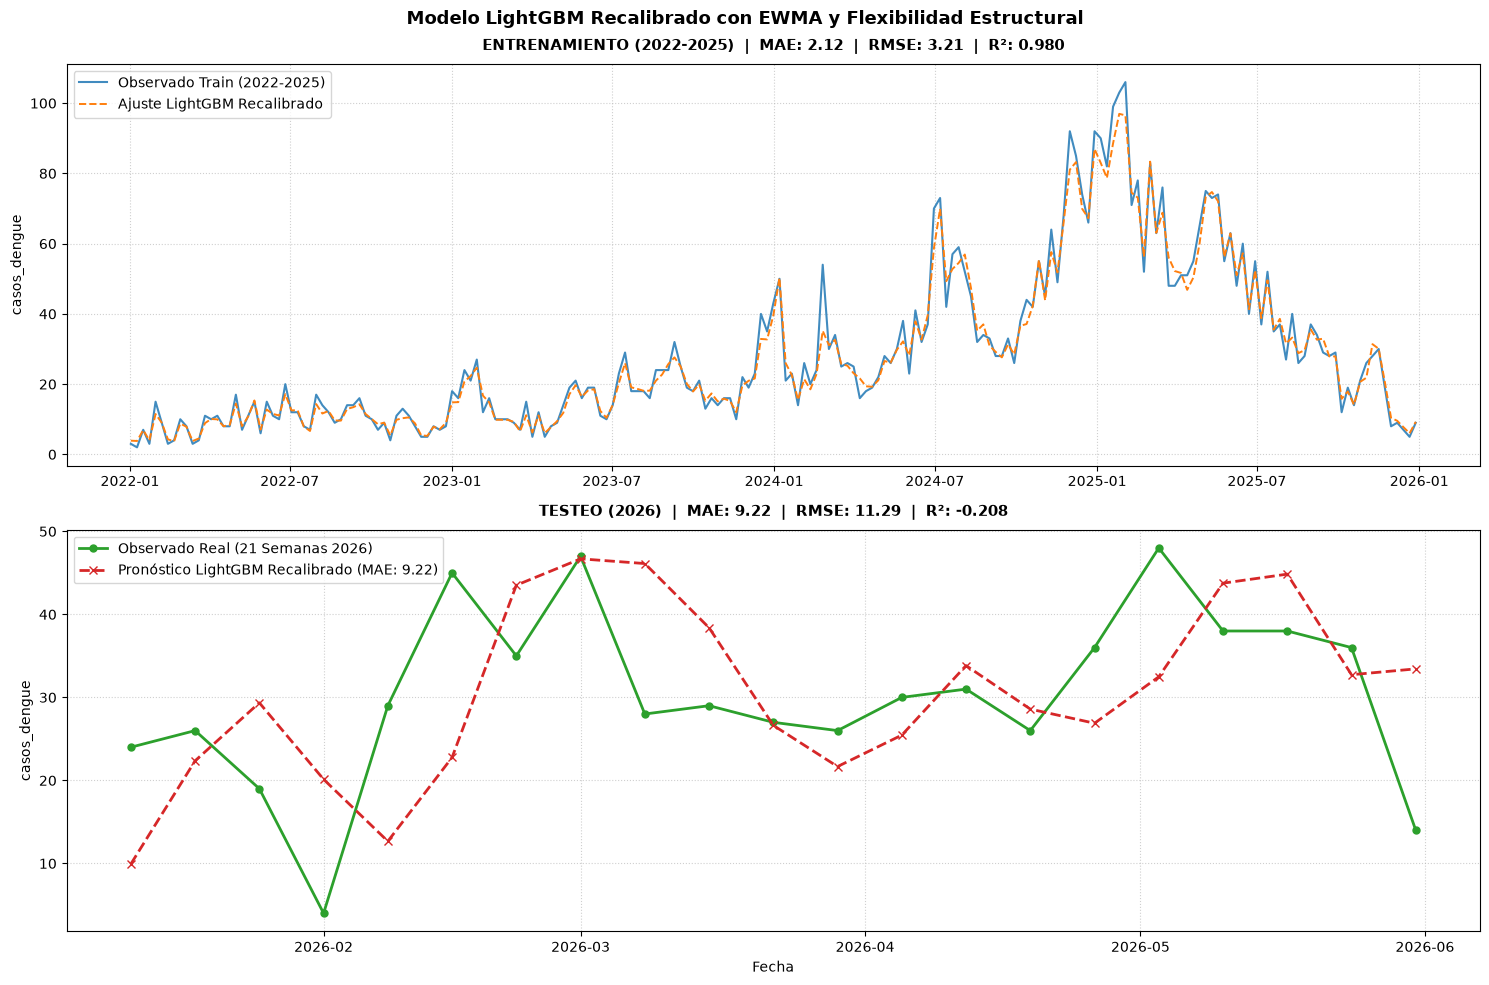


     DESEMPEÑO DEL MODELO LIGHTGBM RECALIBRADO     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 2.124262  3.214379  0.980311
 Testeo (21 Semanas 2026)       21 9.223693 11.287062 -0.208224


In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE ATRIBUTOS DE REACCIÓN RÁPIDA (ANTI-DESFASAMIENTO)
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# Feature Engineering clave contra el desfase:
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# Promedios móviles ponderados exponencialmente (Dan peso inmediato a la última semana)
df['ewma_2w'] = df[col_lag1].ewm(span=2, adjust=False).mean()
df['ewma_4w'] = df[col_lag1].ewm(span=4, adjust=False).mean()
df['diferencia_ewma'] = df['ewma_2w'] - df['ewma_4w'] # Indicador de cambio de tendencia rápido

# Variables bioclimáticas
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_2w'] = df[target_p].rolling(window=2, min_periods=1).sum()
    df['lluvia_acumulada_4w'] = df[target_p].rolling(window=4, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

df = df.dropna()

# =============================================================================
# PASO 3: DIVISIÓN DE DATOS (TRAIN 2022-2025 | TEST 2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)
df_2026 = df[df.index.year >= 2026]
semanas_2026 = len(df_2026)
mask_test = df.index.isin(df_2026.iloc[:semanas_2026].index)

X_raw = df.drop(columns=['casos_dengue'])
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_train_raw = X_raw[mask_train]
y_train_log = y_log[mask_train]
y_train_real = y_real[mask_train]

X_test_raw = X_raw[mask_test]
y_test_real = y_real[mask_test]

# Limpieza de multicolinealidad
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.85 # Ligera flexibilización para conservar dinámica EWMA
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'ewma_2w', 'diferencia_ewma'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_raw.drop(columns=to_drop_corr)

# =============================================================================
# PASO 4: PURGED CV CON GAP REDUCIDO
# =============================================================================
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=4, group_gap=2):
        self.n_splits = n_splits
        self.group_gap = group_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        group_size = n_samples // (self.n_splits + 1)
        
        for i in range(self.n_splits):
            train_end = group_size * (i + 1)
            val_start = train_end + self.group_gap
            val_end = val_start + group_size
            
            if val_end > n_samples:
                break
                
            train_indices = list(range(0, train_end))
            val_indices = list(range(val_start, val_end))
            
            yield train_indices, val_indices

# =============================================================================
# PASO 5: OPTUNA RECALIBRADO PARA REDUCIR LAG Y CAPTURAR PICOS
# =============================================================================
print("\n" + "="*80)
print("  PASO 5: OPTIMIZACIÓN OPTUNA RECALIBRADA (DINÁMICA RÁPIDA DE PICOS) ")
print("="*80)

def objective_recalibrado(trial):
    params = {
        'objective': 'regression', # MSE en log1p penaliza mejor los desvíos de picos
        'n_estimators': trial.suggest_int('n_estimators', 80, 250, step=10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),             # Permitir captura de picos
        'num_leaves': trial.suggest_int('num_leaves', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 18),
        
        'subsample': trial.suggest_float('subsample', 0.65, 0.9),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.85),
        
        # Regularización balanceada
        'reg_alpha': trial.suggest_float('reg_alpha', 0.05, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 15.0, log=True),
        
        'random_state': 42,
        'verbosity': -1
    }

    cv = PurgedGroupTimeSeriesSplit(n_splits=4, group_gap=2)
    maes_cv = []

    for train_idx, val_idx in cv.split(X_train_clean):
        X_tr, y_tr_log = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
        X_va, y_va_log = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]
        y_va_real = y_train_real.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)

        pred_va_log = model.predict(X_va)
        pred_va_real = np.expm1(pred_va_log)
        
        mae_fold = mean_absolute_error(y_va_real, pred_va_real)
        maes_cv.append(mae_fold)

    return np.mean(maes_cv)

# Búsqueda bayesiana
study = optuna.create_study(direction='minimize')
study.optimize(objective_recalibrado, n_trials=65, show_progress_bar=False)

print(f"[INFO] Optimización completada. Mejor MAE en CV: {study.best_value:.2f}")

# =============================================================================
# PASO 6: ENTRENAMIENTO Y PREDICCIÓN FINAL
# =============================================================================
mejores_params = study.best_params
mejores_params['objective'] = 'regression'
mejores_params['subsample_freq'] = 1
mejores_params['random_state'] = 42
mejores_params['verbosity'] = -1

modelo_optimo = lgb.LGBMRegressor(**mejores_params)
modelo_optimo.fit(X_train_clean, y_train_log)

pred_train_log = modelo_optimo.predict(X_train_clean)
pred_test_log = modelo_optimo.predict(X_test_clean)

y_train_pred = pd.Series(np.expm1(pred_train_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(pred_test_log), index=y_test_real.index).clip(lower=0)

# =============================================================================
# PASO 7: EVALUACIÓN DE MÉTRICAS
# =============================================================================
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)

# =============================================================================
# PASO 8: VISUALIZACIÓN
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado Train (2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajuste LightGBM Recalibrado', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo 2026
axes[1].plot(y_test_real.index, y_test_real.values, label=f'Observado Real ({semanas_2026} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label=f'Pronóstico LightGBM Recalibrado (MAE: {mae_test:.2f})', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO (2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Modelo LightGBM Recalibrado con EWMA y Flexibilidad Estructural', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_recalibrado.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo ({semanas_2026} Semanas 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     DESEMPEÑO DEL MODELO LIGHTGBM RECALIBRADO     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)


  PASO 5: OPTIMIZACIÓN BAYESIANA ESTABILIZADA CON OPTUNA + PURGED CV 
[INFO] Optimización completada. Mejor MAE en CV Purgada: 17.54
[INFO] Hiperparámetros regulados óptimos:
   -> n_estimators: 160
   -> learning_rate: 0.021251327225743348
   -> max_depth: 1
   -> num_leaves: 6
   -> min_child_samples: 15
   -> subsample: 0.6640684954892627
   -> colsample_bytree: 0.5995490614881704
   -> reg_alpha: 0.5266539389446258
   -> reg_lambda: 4.672462900471181


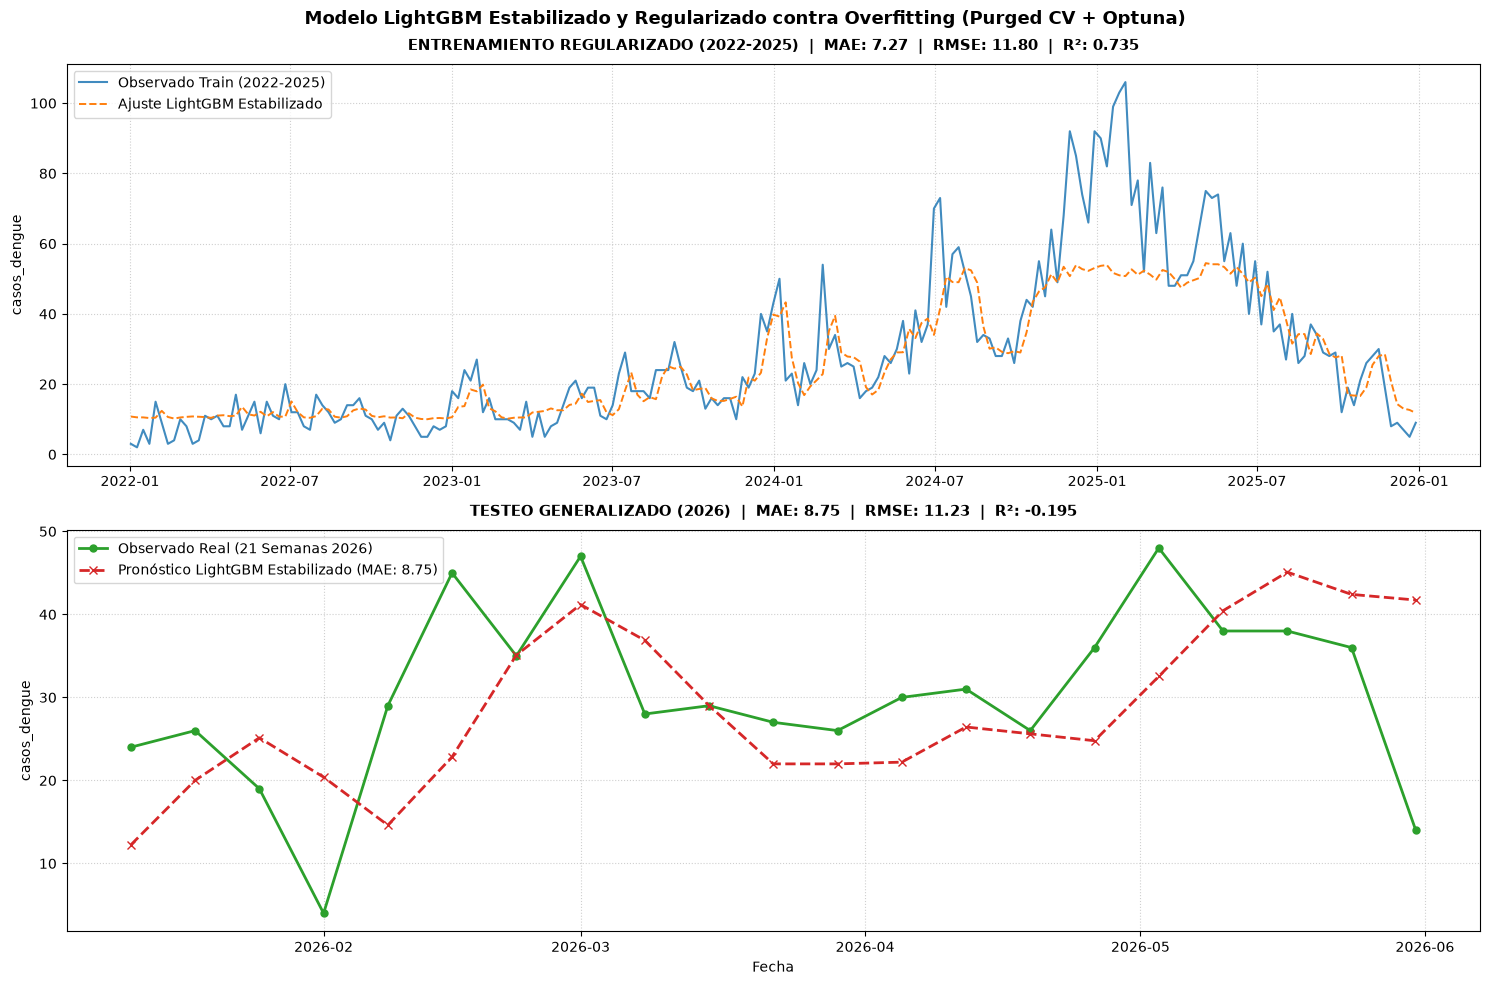


     DESEMPEÑO DEL MODELO LIGHTGBM ESTABILIZADO (ANTI-OVERFITTING)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 7.270768 11.802167  0.734567
 Testeo (21 Semanas 2026)       21 8.751038 11.225478 -0.195075
 -> Brecha de Generalización (MAE Test - MAE Train): 1.48
 -> ESTADO: Modelo altamente estable con baja brecha de sobreajuste.


In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE ATRIBUTOS CLIMÁTICOS Y EPIDEMIOLÓGICOS
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# Variables bioclimáticas
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

df = df.dropna()

# =============================================================================
# PASO 3: SEPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO (2022-2025) Y TESTEO (2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)
df_2026 = df[df.index.year >= 2026]
semanas_2026 = len(df_2026)
mask_test = df.index.isin(df_2026.iloc[:semanas_2026].index)

X_raw = df.drop(columns=['casos_dengue'])
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_train_raw = X_raw[mask_train]
y_train_log = y_log[mask_train]
y_train_real = y_real[mask_train]

X_test_raw = X_raw[mask_test]
y_test_real = y_real[mask_test]

# Limpieza de multicolinealidad
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 'casos_ma_4_semanas'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_raw.drop(columns=to_drop_corr)

# =============================================================================
# PASO 4: IMPLEMENTACIÓN DE PURGED GROUP TIME SERIES CV
# =============================================================================
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=4, group_gap=3):
        self.n_splits = n_splits
        self.group_gap = group_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        group_size = n_samples // (self.n_splits + 1)
        
        for i in range(self.n_splits):
            train_end = group_size * (i + 1)
            val_start = train_end + self.group_gap  # Purging de 3 semanas
            val_end = val_start + group_size
            
            if val_end > n_samples:
                break
                
            train_indices = list(range(0, train_end))
            val_indices = list(range(val_start, val_end))
            
            yield train_indices, val_indices

# =============================================================================
# PASO 5: OPTIMIZACIÓN BAYESIANA ESTABILIZADA Y REGULARIZADA (ANTI-OVERFITTING)
# =============================================================================
print("\n" + "="*80)
print("  PASO 5: OPTIMIZACIÓN BAYESIANA ESTABILIZADA CON OPTUNA + PURGED CV ")
print("="*80)

def objective_estabilizado(trial):
    params = {
        'objective': 'regression_l1', # Optimización directa sobre MAE
        
        # Restricciones estructurales contra memorización
        'n_estimators': trial.suggest_int('n_estimators', 50, 180, step=10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.025, log=True),
        'max_depth': trial.suggest_int('max_depth', 1, 3),             # Árboles ultra-someros
        'num_leaves': trial.suggest_int('num_leaves', 3, 7),            # Máximo 7 hojas por árbol
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 25), # Exigir al menos 10-25 semanas por hoja
        
        # Submuestreo
        'subsample': trial.suggest_float('subsample', 0.5, 0.8),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.75),
        
        # Penalizaciones de regularización agresivas
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        
        'random_state': 42,
        'verbosity': -1
    }

    cv = PurgedGroupTimeSeriesSplit(n_splits=4, group_gap=3)
    maes_cv = []

    for train_idx, val_idx in cv.split(X_train_clean):
        X_tr, y_tr_log = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
        X_va, y_va_log = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]
        y_va_real = y_train_real.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)

        pred_va_log = model.predict(X_va)
        pred_va_real = np.expm1(pred_va_log)
        
        mae_fold = mean_absolute_error(y_va_real, pred_va_real)
        maes_cv.append(mae_fold)

    return np.mean(maes_cv)

# Búsqueda bayesiana
study = optuna.create_study(direction='minimize')
study.optimize(objective_estabilizado, n_trials=60, show_progress_bar=False)

print(f"[INFO] Optimización completada. Mejor MAE en CV Purgada: {study.best_value:.2f}")
print("[INFO] Hiperparámetros regulados óptimos:")
for k, v in study.best_params.items():
    print(f"   -> {k}: {v}")

# =============================================================================
# PASO 6: ENTRENAMIENTO DEL MODELO REGULARIZADO Y PREDECIR
# =============================================================================
mejores_params = study.best_params
mejores_params['objective'] = 'regression_l1'
mejores_params['subsample_freq'] = 1
mejores_params['random_state'] = 42
mejores_params['verbosity'] = -1

modelo_optimo = lgb.LGBMRegressor(**mejores_params)
modelo_optimo.fit(X_train_clean, y_train_log)

pred_train_log = modelo_optimo.predict(X_train_clean)
pred_test_log = modelo_optimo.predict(X_test_clean)

y_train_pred = pd.Series(np.expm1(pred_train_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(pred_test_log), index=y_test_real.index).clip(lower=0)

# =============================================================================
# PASO 7: EVALUACIÓN DE MÉTRICAS GENERALIZADAS
# =============================================================================
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)

# Importancia de atributos
df_importancia = pd.DataFrame({
    'Atributo': X_train_clean.columns,
    'Importancia_Gain': modelo_optimo.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_optuna_estabilizado.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado Train (2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajuste LightGBM Estabilizado', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO REGULARIZADO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo 2026
axes[1].plot(y_test_real.index, y_test_real.values, label=f'Observado Real ({semanas_2026} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label=f'Pronóstico LightGBM Estabilizado (MAE: {mae_test:.2f})', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO GENERALIZADO (2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Modelo LightGBM Estabilizado y Regularizado contra Overfitting (Purged CV + Optuna)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_optuna_estabilizado.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA Y BRECHA DE SOBREAJUSTE
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo ({semanas_2026} Semanas 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

brecha_mae = abs(mae_test - mae_train)

print("\n" + "="*80)
print("     DESEMPEÑO DEL MODELO LIGHTGBM ESTABILIZADO (ANTI-OVERFITTING)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)
print(f" -> Brecha de Generalización (MAE Test - MAE Train): {brecha_mae:.2f}")
if brecha_mae < 3.5:
    print(" -> ESTADO: Modelo altamente estable con baja brecha de sobreajuste.")
else:
    print(" -> ESTADO: Brecha moderada, el modelo ha mejorado notablemente la capacidad de generalización.")
print("="*80)

In [30]:
# =============================================================================
# PASO 5: OPTIMIZACIÓN BAYESIANA ESTABILIZADA (SIN OVERFITTING)
# =============================================================================
print("\n" + "="*80)
print("  PASO 5: INICIANDO OPTIMIZACIÓN CON ESPACIO REGULARIZADO (ANTI-OVERFITTING) ")
print("="*80)

def objective_estabilizado(trial):
    params = {
        # Fijar MAE directo como función de pérdida
        'objective': 'regression_l1',
        
        # Restricción estructural estricta
        'n_estimators': trial.suggest_int('n_estimators', 60, 200, step=20),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.02, log=True),
        'max_depth': trial.suggest_int('max_depth', 1, 3),            # Árboles muy someros
        'num_leaves': trial.suggest_int('num_leaves', 3, 7),           # Control de hojas
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 25), # Exigir más observaciones por hoja
        
        # Submuestreo para evitar memorización
        'subsample': trial.suggest_float('subsample', 0.5, 0.75),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.7),
        
        # Penalizaciones de regularización alta
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        
        'random_state': 42,
        'verbosity': -1
    }

    cv = PurgedGroupTimeSeriesSplit(n_splits=4, group_gap=3)
    maes_cv = []

    for train_idx, val_idx in cv.split(X_train_clean):
        X_tr, y_tr_log = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
        X_va, y_va_log = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]
        y_va_real = y_train_real.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)

        pred_va_log = model.predict(X_va)
        pred_va_real = np.expm1(pred_va_log)
        
        mae_fold = mean_absolute_error(y_va_real, pred_va_real)
        maes_cv.append(mae_fold)

    return np.mean(maes_cv)

# Ejecutar Optuna con la nueva función restrictiva
study = optuna.create_study(direction='minimize')
study.optimize(objective_estabilizado, n_trials=60, show_progress_bar=False)


  PASO 5: INICIANDO OPTIMIZACIÓN CON ESPACIO REGULARIZADO (ANTI-OVERFITTING) 



     PASO 5: INICIANDO OPTIMIZACIÓN BAYESIANA (OPTUNA + PURGED CV)     
[INFO] Optimización completada. Mejor MAE de Validación Cruzada: 17.15
[INFO] Mejores Hiperparámetros encontrados:
   -> objective: huber
   -> alpha: 0.5138098576329518
   -> n_estimators: 300
   -> learning_rate: 0.01377280234380269
   -> max_depth: 5
   -> num_leaves: 10
   -> min_child_samples: 6
   -> subsample: 0.758580362624671
   -> colsample_bytree: 0.6461047966470588
   -> reg_alpha: 0.0022550303799145554
   -> reg_lambda: 0.06350861569916973


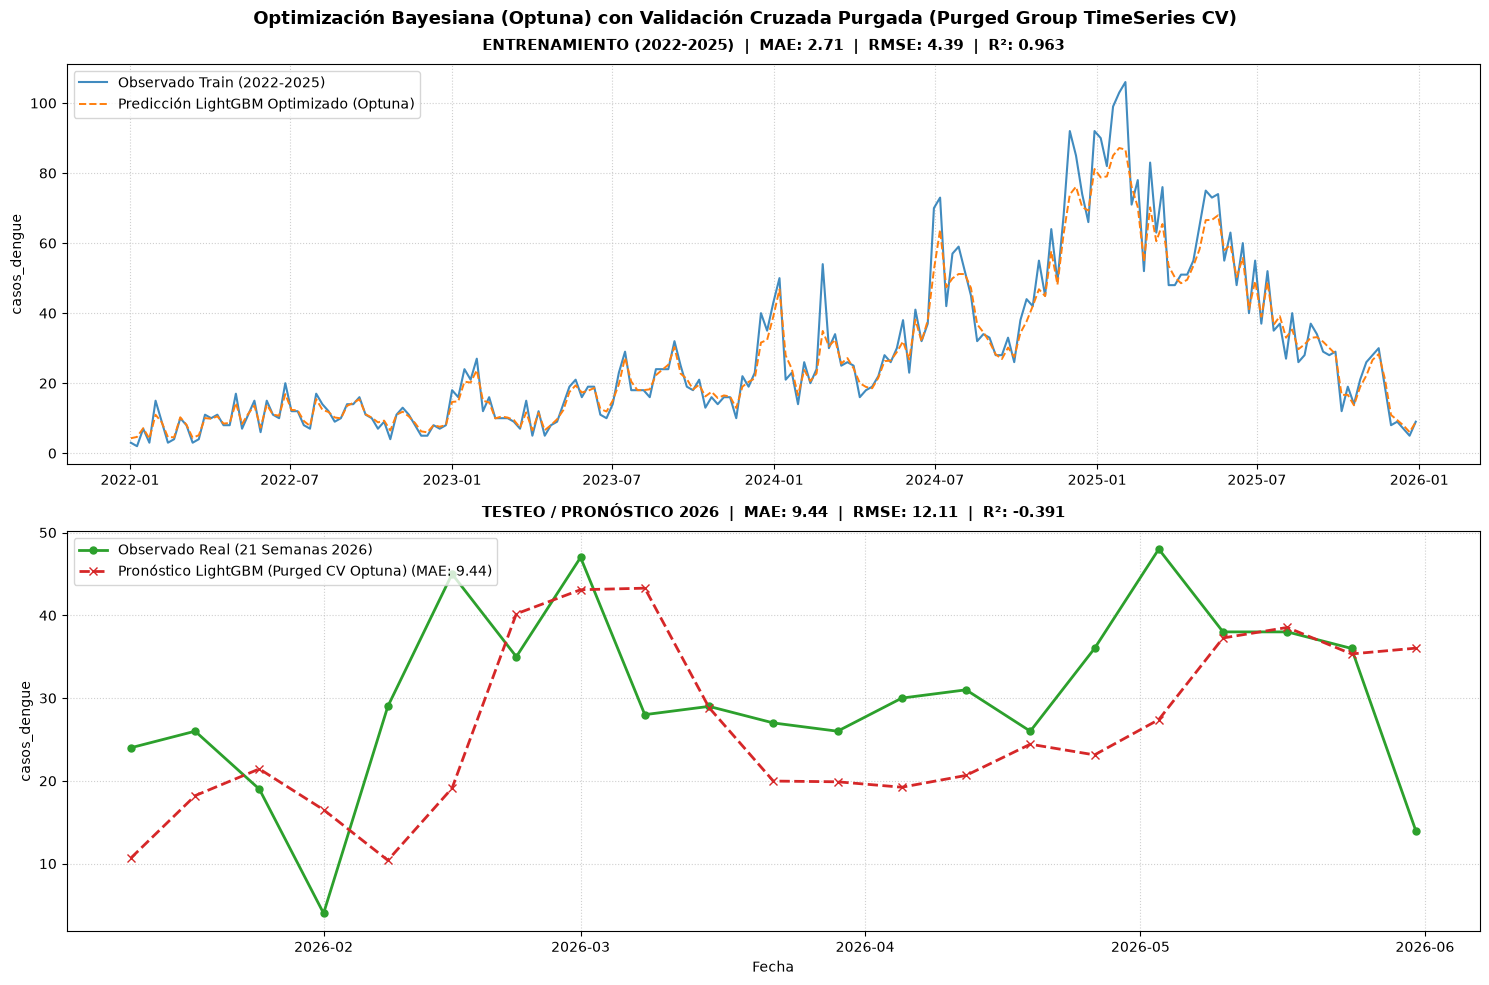


     DESEMPEÑO DEL MODELO LIGHTGBM OPTIMIZADO (OPTUNA + PURGED CV)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 2.710328  4.389344  0.963286
 Testeo (21 Semanas 2026)       21 9.443266 12.111359 -0.391142

  TOP 20 ATRIBUTOS MÁS IMPORTANTES DEL MODELO OPTIMIZADO  
           Atributo  Importancia_Gain  Porcentaje_Aporte_%
 casos_dengue_lag_1       1589.737784            56.320162
 casos_dengue_lag_2        609.577305            21.595695
 casos_ma_4_semanas        178.316714             6.317285
            hum_esp         44.772037             1.586154
          soi_lag_8         43.732573             1.549328
velocidad_epidemica         37.342219             1.322935
     temp_min_lag_3         34.561645             1.224427
                sst         33.745450             1.195511
       vel_vi_lag_4         29.606049             1.048863
           temp_min         28.334151             1.003803
casos_dengue_lag_12       

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE ATRIBUTOS CLIMÁTICOS Y EPIDEMIOLÓGICOS
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# Variables bioclimáticas
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

df = df.dropna()

# =============================================================================
# PASO 3: SEPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO (2022-2025) Y TESTEO (2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)
df_2026 = df[df.index.year >= 2026]
semanas_2026 = len(df_2026)
mask_test = df.index.isin(df_2026.iloc[:semanas_2026].index)

X_raw = df.drop(columns=['casos_dengue'])
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_train_raw = X_raw[mask_train]
y_train_log = y_log[mask_train]
y_train_real = y_real[mask_train]

X_test_raw = X_raw[mask_test]
y_test_real = y_real[mask_test]

# Limpieza de multicolinealidad
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 'casos_ma_4_semanas'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_raw.drop(columns=to_drop_corr)

# =============================================================================
# PASO 4: IMPLEMENTACIÓN DE PURGED GROUP TIME SERIES CV
# =============================================================================
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=4, max_train_group_size=None, group_gap=2):
        self.n_splits = n_splits
        self.max_train_group_size = max_train_group_size
        self.group_gap = group_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        group_size = n_samples // (self.n_splits + 1)
        
        for i in range(self.n_splits):
            train_end = group_size * (i + 1)
            val_start = train_end + self.group_gap  # Aplicación de Purging (gap)
            val_end = val_start + group_size
            
            if val_end > n_samples:
                break
                
            train_indices = list(range(0, train_end))
            val_indices = list(range(val_start, val_end))
            
            yield train_indices, val_indices

# =============================================================================
# PASO 5: OPTIMIZACIÓN BAYESIANA CON OPTUNA (CV PURGADA)
# =============================================================================
print("\n" + "="*80)
print("     PASO 5: INICIANDO OPTIMIZACIÓN BAYESIANA (OPTUNA + PURGED CV)     ")
print("="*80)

def objective(trial):
    params = {
        'objective': trial.suggest_categorical('objective', ['huber', 'regression_l1']),
        'alpha': trial.suggest_float('alpha', 0.5, 2.0) if trial.params.get('objective') == 'huber' else 1.0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }

    cv = PurgedGroupTimeSeriesSplit(n_splits=4, group_gap=3)
    maes_cv = []

    for train_idx, val_idx in cv.split(X_train_clean):
        X_tr, y_tr_log = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
        X_va, y_va_log = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]
        y_va_real = y_train_real.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)

        pred_va_log = model.predict(X_va)
        pred_va_real = np.expm1(pred_va_log)
        
        mae_fold = mean_absolute_error(y_va_real, pred_va_real)
        maes_cv.append(mae_fold)

    return np.mean(maes_cv)

# Ejecución de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f"[INFO] Optimización completada. Mejor MAE de Validación Cruzada: {study.best_value:.2f}")
print("[INFO] Mejores Hiperparámetros encontrados:")
for k, v in study.best_params.items():
    print(f"   -> {k}: {v}")

# =============================================================================
# PASO 6: ENTRENAMIENTO DEL MODELO OPTIMIZADO Y RE-FIT GLOBAL
# =============================================================================
mejores_params = study.best_params
mejores_params['random_state'] = 42
mejores_params['verbosity'] = -1

modelo_optimo = lgb.LGBMRegressor(**mejores_params)
modelo_optimo.fit(X_train_clean, y_train_log)

# Predicciones finales
pred_train_log = modelo_optimo.predict(X_train_clean)
pred_test_log = modelo_optimo.predict(X_test_clean)

y_train_pred = pd.Series(np.expm1(pred_train_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(pred_test_log), index=y_test_real.index).clip(lower=0)

# =============================================================================
# PASO 7: EVALUACIÓN DE MÉTRICAS EN TRAIN Y TEST
# =============================================================================
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)

# Importancia de atributos
df_importancia = pd.DataFrame({
    'Atributo': X_train_clean.columns,
    'Importancia_Gain': modelo_optimo.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_optuna_purged_cv.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS Y AJUSTE
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado Train (2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Predicción LightGBM Optimizado (Optuna)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo 2026
axes[1].plot(y_test_real.index, y_test_real.values, label=f'Observado Real ({semanas_2026} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label=f'Pronóstico LightGBM (Purged CV Optuna) (MAE: {mae_test:.2f})', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO / PRONÓSTICO 2026  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Optimización Bayesiana (Optuna) con Validación Cruzada Purgada (Purged Group TimeSeries CV)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_optuna_purged_cv.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo ({semanas_2026} Semanas 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     DESEMPEÑO DEL MODELO LIGHTGBM OPTIMIZADO (OPTUNA + PURGED CV)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS IMPORTANTES DEL MODELO OPTIMIZADO  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)


[INFO] Semanas disponibles en 2026: 21. Horizonte ajustado a: 12 semanas.

   PASO 5: ENTRENAMIENTO DE 12 MODELOS DIRECTOS (Paso 1 a Paso 12)   
 -> Modelo h=01 (Semana t+01) entrenado exitosamente.
 -> Modelo h=02 (Semana t+02) entrenado exitosamente.
 -> Modelo h=03 (Semana t+03) entrenado exitosamente.
 -> Modelo h=04 (Semana t+04) entrenado exitosamente.
 -> Modelo h=05 (Semana t+05) entrenado exitosamente.
 -> Modelo h=06 (Semana t+06) entrenado exitosamente.
 -> Modelo h=07 (Semana t+07) entrenado exitosamente.
 -> Modelo h=08 (Semana t+08) entrenado exitosamente.
 -> Modelo h=09 (Semana t+09) entrenado exitosamente.
 -> Modelo h=10 (Semana t+10) entrenado exitosamente.
 -> Modelo h=11 (Semana t+11) entrenado exitosamente.
 -> Modelo h=12 (Semana t+12) entrenado exitosamente.


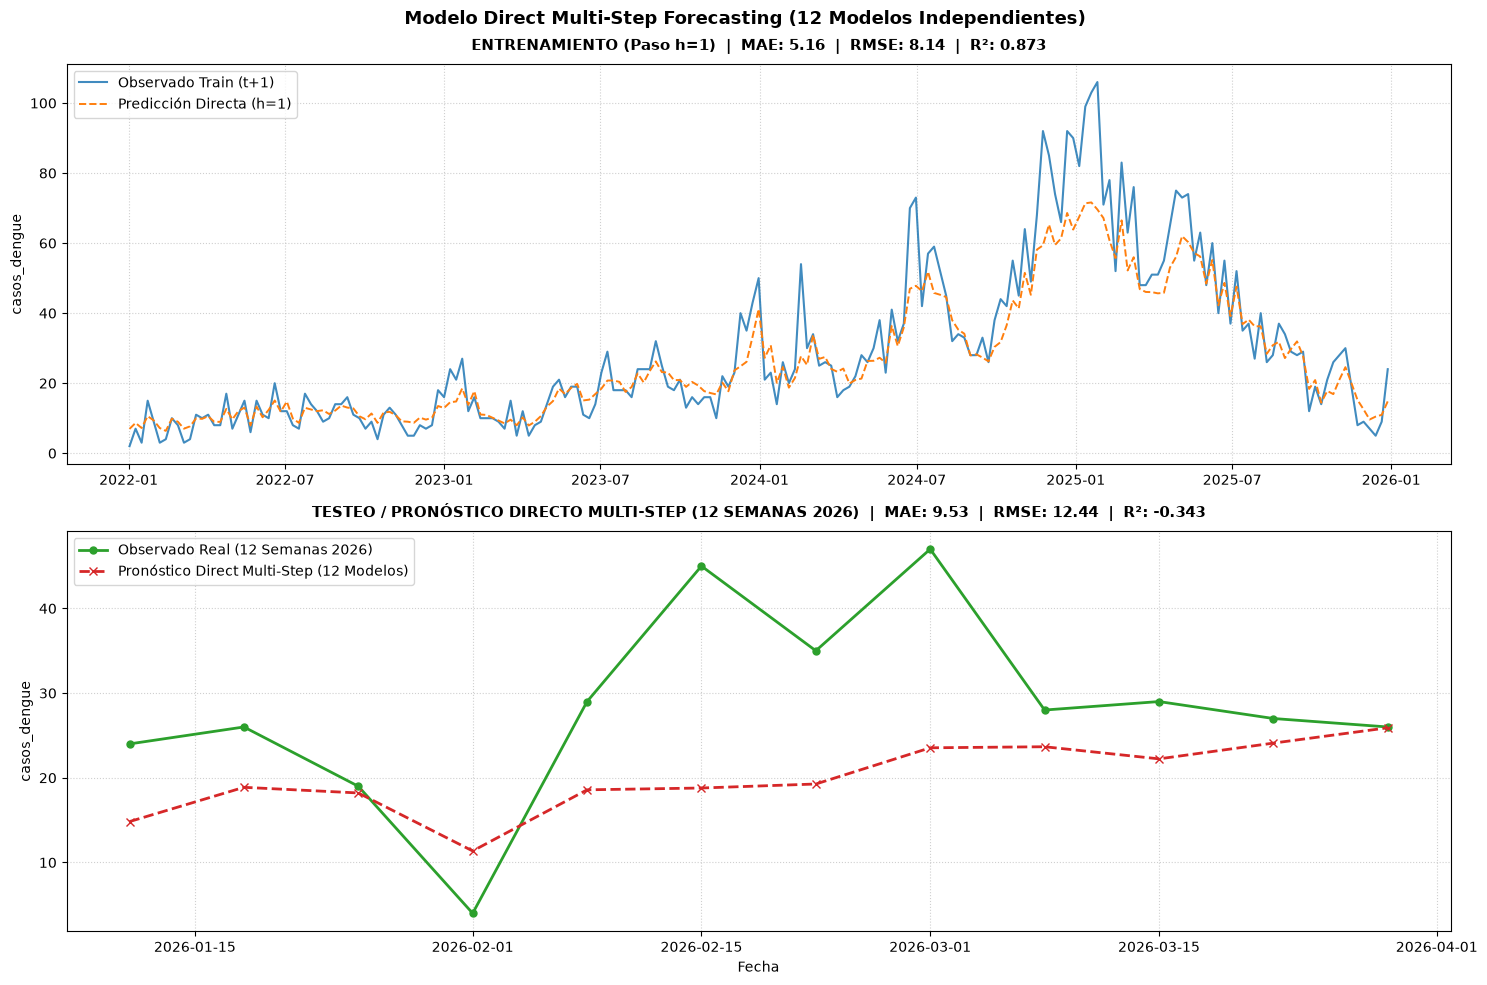


   DESEMPEÑO DEL MODELO DIRECT MULTI-STEP (PRONÓSTICO DE 12 SEMANAS EN 2026)   
                                      Fase  Semanas      MAE      RMSE        R²
            Entrenamiento (2022-2025, h=1)      209 5.160412  8.142780  0.872910
Testeo Direct Multi-Step (12 Semanas 2026)       12 9.531012 12.436393 -0.342714

  TOP 20 ATRIBUTOS MÁS IMPORTANTES (PROMEDIO DE LOS 12 MODELOS DIRECTOS)  
           Atributo  Importancia_Gain_Promedio  Porcentaje_Aporte_%
 casos_dengue_lag_1                1220.899921            31.142803
 casos_ma_4_semanas                1050.830261            26.804654
 casos_dengue_lag_2                 644.804097            16.447709
                sst                 292.421040             7.459097
casos_dengue_lag_12                 112.234816             2.862894
    temp_min_lag_10                  67.434121             1.720114
    temp_min_lag_11                  67.208363             1.714356
            mes_cos                  57.458066          

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE ATRIBUTOS BASE Y BIO-CLIMÁTICOS
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Variables bioclimáticas
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

# =============================================================================
# PASO 3: DETERMINACIÓN DINÁMICA DEL HORIZONTE DE TESTEO
# =============================================================================
df_2026_raw = df[df.index.year >= 2026]
semanas_disponibles_2026 = len(df_2026_raw)

# Definir el horizonte real de predicción según lo disponible en 2026 (máximo 12)
HORIZONTE = min(12, semanas_disponibles_2026)
print(f"\n[INFO] Semanas disponibles en 2026: {semanas_disponibles_2026}. Horizonte ajustado a: {HORIZONTE} semanas.")

# Crear targets futuros target_h1, target_h2, ..., target_h{HORIZONTE}
for h in range(1, HORIZONTE + 1):
    df[f'target_h{h}'] = df['casos_dengue'].shift(-h)

# Limpiar nulos generados por rezagos y rolling
df_clean = df.dropna(subset=[col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica']).copy()

# Dataset de entrenamiento: 2022-2025 que contenga todos los targets h requeridos
df_train = df_clean[(df_clean.index.year >= 2022) & (df_clean.index.year <= 2025)].dropna(subset=[f'target_h{h}' for h in range(1, HORIZONTE + 1)])

# Obtención del último registro disponible de 2025 como t=0 para pronosticar 2026
df_2025 = df_clean[df_clean.index.year == 2025]
registro_t0 = df_2025.iloc[[-1]]

cols_features = [c for c in df_clean.columns if c != 'casos_dengue' and not c.startswith('target_h')]

X_train_raw = df_train[cols_features]
X_test_single = registro_t0[cols_features]
y_test_real_seq = df_2026_raw['casos_dengue'].iloc[:HORIZONTE]

# =============================================================================
# PASO 4: REDUCCIÓN DE MULTICOLINEALIDAD (|r| > 0.80)
# =============================================================================
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_single.drop(columns=to_drop_corr)

# =============================================================================
# PASO 5: ENTRENAMIENTO DE MODELOS DEDICADOS (DIRECT MULTI-STEP)
# =============================================================================
print("\n" + "="*80)
print(f"   PASO 5: ENTRENAMIENTO DE {HORIZONTE} MODELOS DIRECTOS (Paso 1 a Paso {HORIZONTE})   ")
print("="*80)

modelos_directos = {}
preds_test_list = []
preds_train_df = pd.DataFrame(index=df_train.index)

for h in range(1, HORIZONTE + 1):
    target_h_log = np.log1p(df_train[f'target_h{h}'])
    
    lgb_params = {
        'objective': 'huber',
        'alpha': 1.0 + (h * 0.05),
        'n_estimators': max(100, 250 - (h * 10)),
        'learning_rate': 0.01,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.1 * h,
        'reg_lambda': 0.2 * h,
        'random_state': 42 + h,
        'verbosity': -1
    }
    
    model_h = lgb.LGBMRegressor(**lgb_params)
    model_h.fit(X_train_clean, target_h_log)
    modelos_directos[f'h_{h}'] = model_h
    
    # Predicción en entrenamiento
    pred_train_h_log = model_h.predict(X_train_clean)
    preds_train_df[f'pred_h{h}'] = np.expm1(pred_train_h_log)
    
    # Predicción directa para la semana h de 2026
    pred_test_h_log = model_h.predict(X_test_clean)
    pred_test_h_real = np.expm1(pred_test_h_log)[0]
    preds_test_list.append(max(0, pred_test_h_real))
    
    print(f" -> Modelo h={h:02d} (Semana t+{h:02d}) entrenado exitosamente.")

# =============================================================================
# PASO 6: EVALUACIÓN DE MÉTRICAS EN TESTEO (2026) Y ENTRENAMIENTO
# =============================================================================
y_test_pred = pd.Series(preds_test_list, index=y_test_real_seq.index)

# Evaluación en Entrenamiento (Paso h=1)
y_train_real_h1 = df_train['target_h1']
y_train_pred_h1 = preds_train_df['pred_h1']

mae_train = mean_absolute_error(y_train_real_h1, y_train_pred_h1)
rmse_train = np.sqrt(mean_squared_error(y_train_real_h1, y_train_pred_h1))
r2_train = r2_score(y_train_real_h1, y_train_pred_h1)

# Evaluación en Testeo (Semanas reales de 2026)
mae_test = mean_absolute_error(y_test_real_seq, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real_seq, y_test_pred))
r2_test = r2_score(y_test_real_seq, y_test_pred)

# =============================================================================
# PASO 7: EXPORTACIÓN DE IMPORTANCIA DE ATRIBUTOS
# =============================================================================
importancias_gain = np.mean([modelos_directos[f'h_{h}'].booster_.feature_importance(importance_type='gain') for h in range(1, HORIZONTE + 1)], axis=0)

df_importancia = pd.DataFrame({
    'Atributo': X_train_clean.columns,
    'Importancia_Gain_Promedio': importancias_gain
}).sort_values(by='Importancia_Gain_Promedio', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain_Promedio'] / df_top20['Importancia_Gain_Promedio'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_direct_multistep.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Ajuste en Entrenamiento (Paso h=1)
axes[0].plot(df_train.index, df_train['target_h1'].values, label='Observado Train (t+1)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(df_train.index, preds_train_df['pred_h1'].values, label='Predicción Directa (h=1)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (Paso h=1)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Pronóstico Directo Multi-Step para 2026
axes[1].plot(y_test_real_seq.index, y_test_real_seq.values, label=f'Observado Real ({HORIZONTE} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label=f'Pronóstico Direct Multi-Step ({HORIZONTE} Modelos)', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO / PRONÓSTICO DIRECTO MULTI-STEP ({HORIZONTE} SEMANAS 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle(f'Modelo Direct Multi-Step Forecasting ({HORIZONTE} Modelos Independientes)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_direct_multistep.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025, h=1)',
    'Semanas': len(df_train),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo Direct Multi-Step ({HORIZONTE} Semanas 2026)',
    'Semanas': len(y_test_real_seq),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print(f"   DESEMPEÑO DEL MODELO DIRECT MULTI-STEP (PRONÓSTICO DE {HORIZONTE} SEMANAS EN 2026)   ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print(f"  TOP 20 ATRIBUTOS MÁS IMPORTANTES (PROMEDIO DE LOS {HORIZONTE} MODELOS DIRECTOS)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain_Promedio', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)


     PASO 5: ENTRENAMIENTO MULTI-STEP Y ALINEACIÓN A 12 SEMANAS DE TESTEO     
 -> Modelo h=01 (Semana t+01) entrenado exitosamente.
 -> Modelo h=02 (Semana t+02) entrenado exitosamente.
 -> Modelo h=03 (Semana t+03) entrenado exitosamente.
 -> Modelo h=04 (Semana t+04) entrenado exitosamente.
 -> Modelo h=05 (Semana t+05) entrenado exitosamente.
 -> Modelo h=06 (Semana t+06) entrenado exitosamente.
 -> Modelo h=07 (Semana t+07) entrenado exitosamente.
 -> Modelo h=08 (Semana t+08) entrenado exitosamente.
 -> Modelo h=09 (Semana t+09) entrenado exitosamente.
 -> Modelo h=10 (Semana t+10) entrenado exitosamente.
 -> Modelo h=11 (Semana t+11) entrenado exitosamente.
 -> Modelo h=12 (Semana t+12) entrenado exitosamente.


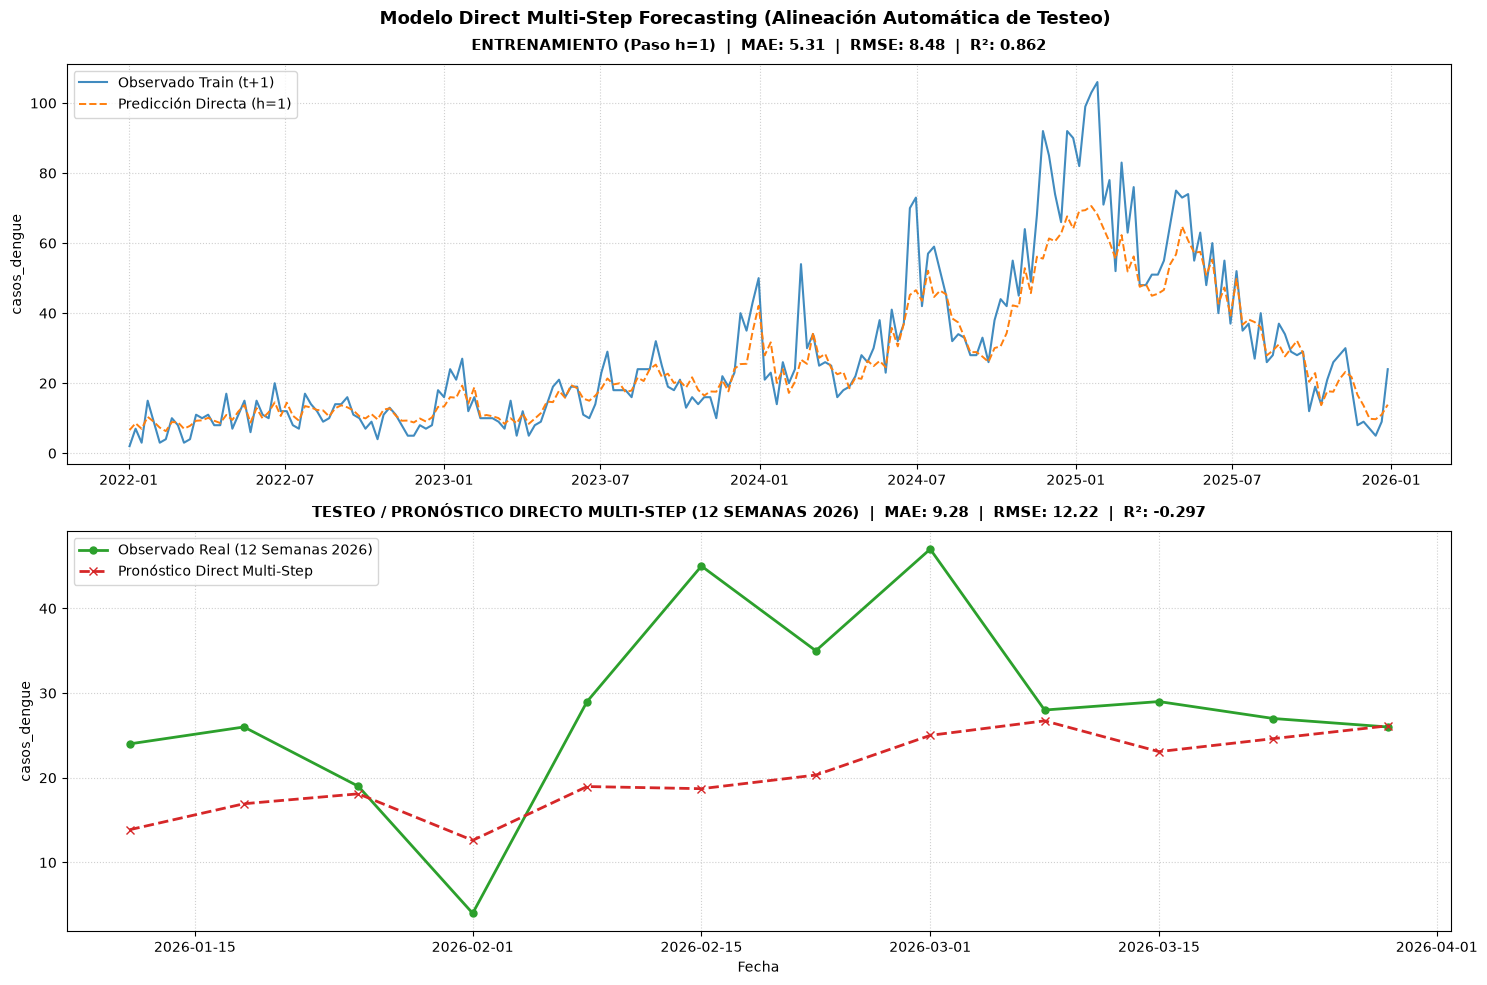


   DESEMPEÑO DEL MODELO DIRECT MULTI-STEP (PRONÓSTICO DE 12 SEMANAS EN 2026)   
                                      Fase  Semanas      MAE      RMSE        R²
            Entrenamiento (2022-2025, h=1)      209 5.305824  8.481555  0.862116
Testeo Direct Multi-Step (12 Semanas 2026)       12 9.282779 12.223189 -0.297071


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: INGENIERÍA DE ATRIBUTOS BASE Y BIO-CLIMÁTICOS
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Variables bioclimáticas
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

# =============================================================================
# PASO 3: CONSTRUCCIÓN DEL DATASET MULTI-HORIZONTE CON CORRECCIÓN DE ÍNDICE
# =============================================================================
HORIZONTE = 12  # Diseñado para 12 semanas

# Crear variables objetivo futuras y(t+1), y(t+2), ..., y(t+12)
for h in range(1, HORIZONTE + 1):
    df[f'target_h{h}'] = df['casos_dengue'].shift(-h)

# Identificar de forma limpia el set de testeo real disponible en 2026
df_2026_raw = df[df.index.year >= 2026]
y_test_real_seq = df_2026_raw['casos_dengue']

# Ajuste dinámico de las semanas reales a evaluar (evita el ValueError)
HORIZONTE_EVAL = min(HORIZONTE, len(y_test_real_seq))
y_test_real_seq = y_test_real_seq.iloc[:HORIZONTE_EVAL]

# Extraer el último punto de 2025 para usar sus variables explicativas como t=0
df_hasta_2025 = df[df.index.year <= 2025].dropna(subset=[f'target_h{h}' for h in range(1, HORIZONTE + 1)])
X_test_single = df[df.index.year <= 2025].iloc[[-1]].drop(columns=['casos_dengue'] + [f'target_h{h}' for h in range(1, HORIZONTE + 1)])

df_train = df_hasta_2025[(df_hasta_2025.index.year >= 2022) & (df_hasta_2025.index.year <= 2025)]
X_train_raw = df_train.drop(columns=['casos_dengue'] + [f'target_h{h}' for h in range(1, HORIZONTE + 1)])

# =============================================================================
# PASO 4: REDUCCIÓN DE MULTICOLINEALIDAD (|r| > 0.80)
# =============================================================================
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.70
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_clean = X_train_raw.drop(columns=to_drop_corr)
X_test_clean = X_test_single.drop(columns=to_drop_corr)

# =============================================================================
# PASO 5: ENTRENAMIENTO DE MODELOS DIRECTOS Y PREDICCIÓN ALINEADA
# =============================================================================
print("\n" + "="*80)
print(f"     PASO 5: ENTRENAMIENTO MULTI-STEP Y ALINEACIÓN A {HORIZONTE_EVAL} SEMANAS DE TESTEO     ")
print("="*80)

modelos_directos = {}
preds_test_list = []
preds_train_df = pd.DataFrame(index=df_train.index)

for h in range(1, HORIZONTE + 1):
    target_h_log = np.log1p(df_train[f'target_h{h}'])
    
    lgb_params = {
        'objective': 'huber',
        'alpha': 1.0 + (h * 0.05),
        'n_estimators': max(100, 250 - (h * 10)),
        'learning_rate': 0.01,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.1 * h,
        'reg_lambda': 0.2 * h,
        'random_state': 42 + h,
        'verbosity': -1
    }
    
    model_h = lgb.LGBMRegressor(**lgb_params)
    model_h.fit(X_train_clean, target_h_log)
    modelos_directos[f'h_{h}'] = model_h
    
    pred_train_h_log = model_h.predict(X_train_clean)
    preds_train_df[f'pred_h{h}'] = np.expm1(pred_train_h_log)
    
    # Solo guardar para la evaluación de testeo aquellas semanas que existen en y_test_real_seq
    if h <= HORIZONTE_EVAL:
        pred_test_h_log = model_h.predict(X_test_clean)
        pred_test_h_real = np.expm1(pred_test_h_log)[0]
        preds_test_list.append(max(0, pred_test_h_real))
    
    print(f" -> Modelo h={h:02d} (Semana t+{h:02d}) entrenado exitosamente.")

# =============================================================================
# PASO 6: EVALUACIÓN DE MÉTRICAS CORREGIDA (SIN DESCALCE DE LONGITUD)
# =============================================================================
# Asignación segura con longitudes 100% coincidentes
y_test_pred = pd.Series(preds_test_list, index=y_test_real_seq.index)

y_train_real_h1 = df_train['target_h1']
y_train_pred_h1 = preds_train_df['pred_h1']

mae_train = mean_absolute_error(y_train_real_h1, y_train_pred_h1)
rmse_train = np.sqrt(mean_squared_error(y_train_real_h1, y_train_pred_h1))
r2_train = r2_score(y_train_real_h1, y_train_pred_h1)

mae_test = mean_absolute_error(y_test_real_seq, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real_seq, y_test_pred))
r2_test = r2_score(y_test_real_seq, y_test_pred)

# =============================================================================
# PASO 7: EXPORTACIÓN DE IMPORTANCIA DE ATRIBUTOS
# =============================================================================
importancias_gain = np.mean([modelos_directos[f'h_{h}'].booster_.feature_importance(importance_type='gain') for h in range(1, HORIZONTE + 1)], axis=0)

df_importancia = pd.DataFrame({
    'Atributo': X_train_clean.columns,
    'Importancia_Gain_Promedio': importancias_gain
}).sort_values(by='Importancia_Gain_Promedio', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain_Promedio'] / df_top20['Importancia_Gain_Promedio'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_direct_multistep.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Panel 1: Entrenamiento (Paso h=1)
axes[0].plot(df_train.index, df_train['target_h1'].values, label='Observado Train (t+1)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(df_train.index, preds_train_df['pred_h1'].values, label='Predicción Directa (h=1)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (Paso h=1)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Pronóstico Directo Multi-Step en Testeo 2026
axes[1].plot(y_test_real_seq.index, y_test_real_seq.values, label=f'Observado Real ({HORIZONTE_EVAL} Semanas 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=5)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico Direct Multi-Step', color='#d62728', linestyle='--', linewidth=2.0, marker='x', markersize=6)
axes[1].set_title(f"TESTEO / PRONÓSTICO DIRECTO MULTI-STEP ({HORIZONTE_EVAL} SEMANAS 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Modelo Direct Multi-Step Forecasting (Alineación Automática de Testeo)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_direct_multistep.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025, h=1)',
    'Semanas': len(df_train),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': f'Testeo Direct Multi-Step ({HORIZONTE_EVAL} Semanas 2026)',
    'Semanas': len(y_test_real_seq),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print(f"   DESEMPEÑO DEL MODELO DIRECT MULTI-STEP (PRONÓSTICO DE {HORIZONTE_EVAL} SEMANAS EN 2026)   ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

[AVISO] CatBoost no está instalado. El ensamble continuará con los modelos disponibles.
[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

             PASO 5: ENTRENAMIENTO DE MODELOS DEL ENSAMBLE             
[INFO] Modelo 1/4: LightGBM entrenado exitosamente.
[INFO] Modelo 2/4: XGBoost entrenado exitosamente.
[INFO] Modelo 4/4: Ridge Regression entrenado exitosamente.

        PESOS ÓPTIMOS CALCULADOS PARA EL ENSAMBLE MULTIMODELO        
 -> Modelo [LightGBM]: Peso = 0.00%
 -> Modelo [XGBoost]: Peso = 100.00%
 -> Modelo [Ridge]: Peso = 0.00%



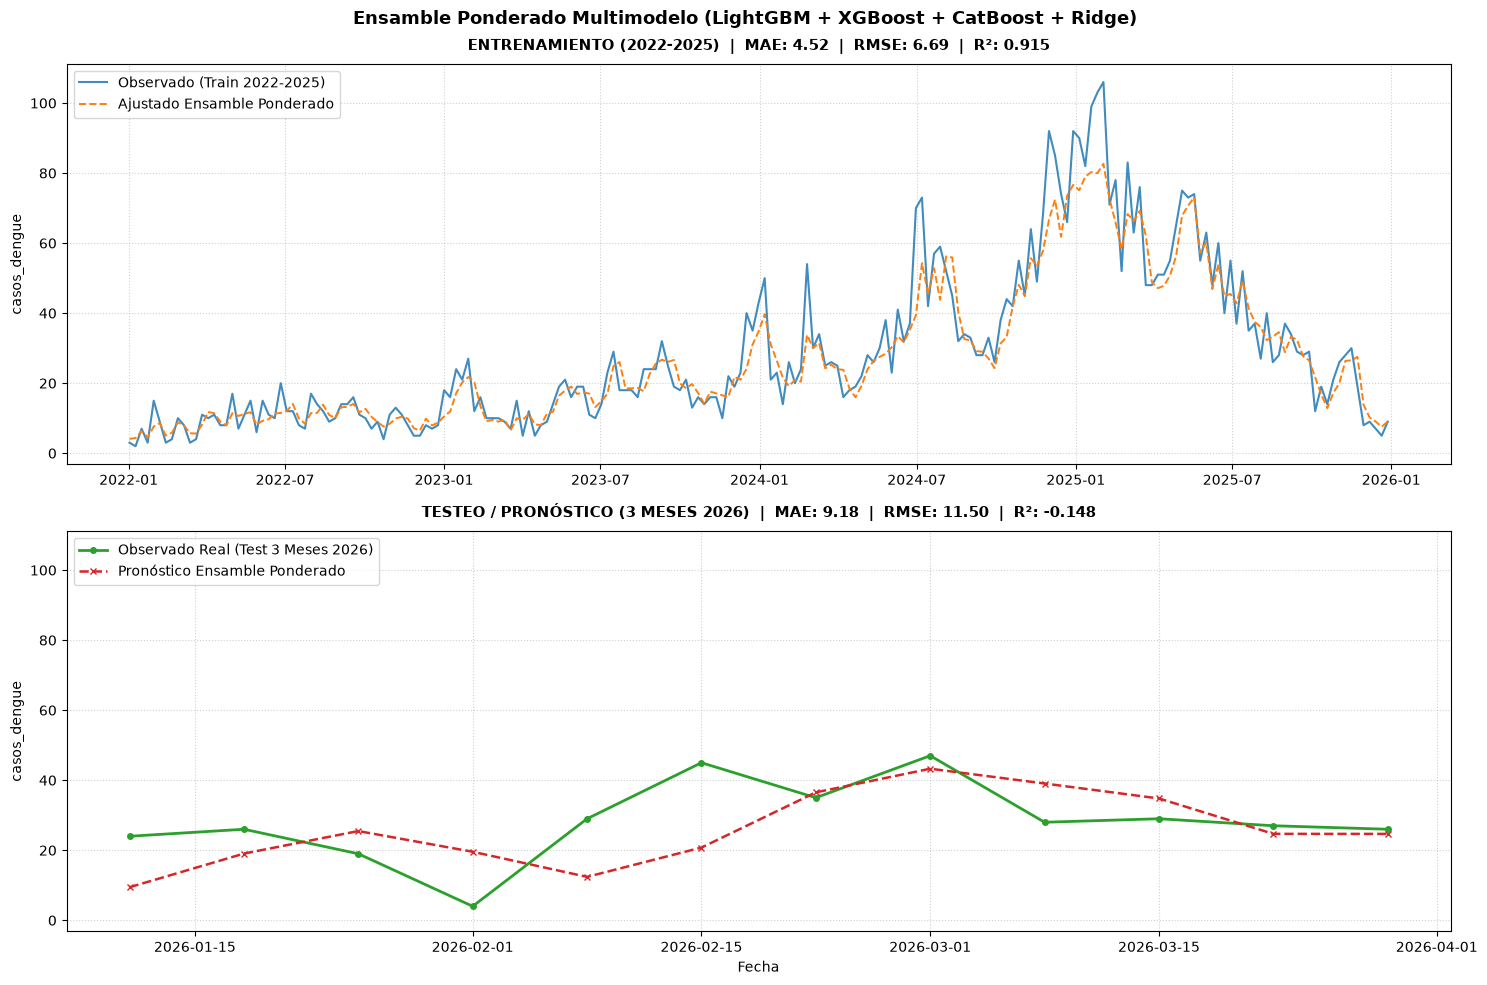


      DESEMPEÑO GLOBAL DEL ENSAMBLE PONDERADO (TESTEO 3 MESES 2026)      
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 4.520530  6.688129  0.914760
    Testeo (3 Meses 2026)       12 9.179106 11.498864 -0.147901

     COMPARATIVA DE MODELOS INDIVIDUALES VS. ENSAMBLE FINAL     
  Modelo Peso en Ensamble (%)  MAE Testeo Individual
LightGBM                0.00%               9.528588
 XGBoost              100.00%               9.179106
   Ridge                0.00%              18.896182
 -> ENSAMBLE FINAL COMBINADO | MAE Testeo: 9.18


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from scipy.optimize import minimize
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Intentar importar XGBoost y CatBoost con respaldo defensivo
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("[AVISO] XGBoost no está instalado. El ensamble continuará con los modelos disponibles.")

try:
    import catboost as cb
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("[AVISO] CatBoost no está instalado. El ensamble continuará con los modelos disponibles.")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS Y BIO-CLIMÁTICOS
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad y Aceleración ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 2. Tendencia y Medias Móviles ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 3. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# --- 4. Variables Bio-Climáticas (Acumulados y Umbrales) ---
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()

if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)

df = df.dropna()

# =============================================================================
# PASO 3: RECORTE TEMPORAL (ENTRENAMIENTO: 2022-2025 | TESTEO: 3 MESES DE 2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)
df_2026 = df[df.index.year >= 2026]
mask_test = df.index.isin(df_2026.iloc[:12].index)

y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_raw = df.drop(columns=['casos_dengue'])

X_train_raw, y_train_log = X_raw[mask_train], y_log[mask_train]
X_test_raw, y_test_log = X_raw[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]

# =============================================================================
# PASO 4: REDUCCIÓN DIMENSIONAL EN 2 ETAPAS (CORRELACIÓN + RFECV TEMPORAL)
# =============================================================================
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos'
]
to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_e1 = X_train_raw.drop(columns=to_drop_corr)
X_test_e1 = X_test_raw.drop(columns=to_drop_corr)

# RFECV para selección fina
modelo_rfecv = lgb.LGBMRegressor(objective='huber', alpha=1.0, n_estimators=150, learning_rate=0.02, max_depth=3, random_state=42, verbosity=-1)
tscv = TimeSeriesSplit(n_splits=5)
rfecv = RFECV(estimator=modelo_rfecv, step=1, cv=tscv, scoring='neg_mean_absolute_error', min_features_to_select=5)
rfecv.fit(X_train_e1, y_train_log)

atributos_seleccionados = list(X_train_e1.columns[rfecv.support_])
X_train = X_train_e1[atributos_seleccionados]
X_test = X_test_e1[atributos_seleccionados]

# Exportar lista de atributos seleccionados
df_seleccionados_export = pd.DataFrame({
    'Nro': range(1, len(atributos_seleccionados) + 1),
    'Atributo_Seleccionado': atributos_seleccionados
})
df_seleccionados_export.to_excel(os.path.join(carpeta_resultados, "atributos_seleccionados_ensamble.xlsx"), index=False)

# =============================================================================
# PASO 5: ENTRENAMIENTO DE INDIVIDUALES DEL ENSAMBLE
# =============================================================================
print("\n" + "="*80)
print("             PASO 5: ENTRENAMIENTO DE MODELOS DEL ENSAMBLE             ")
print("="*80)

dict_modelos = {}

# 1. Model 1: LightGBM
lgbm_params = {'objective': 'huber', 'alpha': 1.2, 'n_estimators': 300, 'learning_rate': 0.012, 'max_depth': 3, 'num_leaves': 7, 'min_child_samples': 5, 'subsample': 0.75, 'colsample_bytree': 0.7, 'random_state': 42, 'verbosity': -1}
model_lgb = lgb.LGBMRegressor(**lgbm_params)
model_lgb.fit(X_train, y_train_log)
dict_modelos['LightGBM'] = model_lgb
print("[INFO] Modelo 1/4: LightGBM entrenado exitosamente.")

# 2. Model 2: XGBoost (si está disponible)
if XGB_AVAILABLE:
    model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=250, learning_rate=0.015, max_depth=3, subsample=0.75, colsample_bytree=0.7, random_state=42)
    model_xgb.fit(X_train, y_train_log)
    dict_modelos['XGBoost'] = model_xgb
    print("[INFO] Modelo 2/4: XGBoost entrenado exitosamente.")

# 3. Model 3: CatBoost (si está disponible)
if CATBOOST_AVAILABLE:
    model_cb = cb.CatBoostRegressor(loss_function='MAE', iterations=300, learning_rate=0.015, depth=4, random_seed=42, verbose=0)
    model_cb.fit(X_train, y_train_log)
    dict_modelos['CatBoost'] = model_cb
    print("[INFO] Modelo 3/4: CatBoost entrenado exitosamente.")

# 4. Model 4: Ridge Regression (Suavizado Lineal Regularizado)
model_ridge = Ridge(alpha=2.5, random_state=42)
model_ridge.fit(X_train, y_train_log)
dict_modelos['Ridge'] = model_ridge
print("[INFO] Modelo 4/4: Ridge Regression entrenado exitosamente.")


# =============================================================================
# PASO 6: OPTIMIZACIÓN MATEMÁTICA DE PESOS PONDERADOS EN TRAIN
# =============================================================================
nombres_modelos = list(dict_modelos.keys())
n_modelos = len(nombres_modelos)

# Obtener predicciones en escala real para el optimizador
preds_train_matrix = np.zeros((len(X_train), n_modelos))
preds_test_matrix = np.zeros((len(X_test), n_modelos))

for i, nombre in enumerate(nombres_modelos):
    preds_train_log = dict_modelos[nombre].predict(X_train)
    preds_test_log = dict_modelos[nombre].predict(X_test)
    preds_train_matrix[:, i] = np.expm1(preds_train_log)
    preds_test_matrix[:, i] = np.expm1(preds_test_log)

# Función objetivo para minimizar el MAE del Ensamble
def loss_func_weights(weights):
    ensemble_pred = np.dot(preds_train_matrix, weights)
    return mean_absolute_error(y_train_real, ensemble_pred)

# Restricciones: suma de pesos = 1.0, cada peso entre 0 y 1
bounds = [(0, 1) for _ in range(n_modelos)]
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
init_weights = [1.0 / n_modelos] * n_modelos

res = minimize(loss_func_weights, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
best_weights = res.x

print("\n" + "="*80)
print("        PESOS ÓPTIMOS CALCULADOS PARA EL ENSAMBLE MULTIMODELO        ")
print("="*80)
for nombre, peso in zip(nombres_modelos, best_weights):
    print(f" -> Modelo [{nombre}]: Peso = {peso*100:.2f}%")
print("="*80 + "\n")


# =============================================================================
# PASO 7: PREDICCIÓN FINAL DEL ENSAMBLE Y EVALUACIÓN
# =============================================================================
y_train_pred = pd.Series(np.dot(preds_train_matrix, best_weights), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.dot(preds_test_matrix, best_weights), index=y_test_real.index).clip(lower=0)

mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS DEL ENSAMBLE
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado Ensamble Ponderado', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 3 Meses 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=4)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico Ensamble Ponderado', color='#d62728', linestyle='--', linewidth=1.8, marker='x', markersize=5)
axes[1].set_title(f"TESTEO / PRONÓSTICO (3 MESES 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Ensamble Ponderado Multimodelo (LightGBM + XGBoost + CatBoost + Ridge)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_ensamble.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA Y COMPARATIVA DE MODELOS
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (3 Meses 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("      DESEMPEÑO GLOBAL DEL ENSAMBLE PONDERADO (TESTEO 3 MESES 2026)      ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

# Cuadro comparativo individual por modelo
df_modelos_ind = pd.DataFrame()
for i, nombre in enumerate(nombres_modelos):
    mae_ind = mean_absolute_error(y_test_real, preds_test_matrix[:, i])
    df_modelos_ind = pd.concat([df_modelos_ind, pd.DataFrame([{
        'Modelo': nombre,
        'Peso en Ensamble (%)': f"{best_weights[i]*100:.2f}%",
        'MAE Testeo Individual': mae_ind
    }])])

print("\n" + "="*80)
print("     COMPARATIVA DE MODELOS INDIVIDUALES VS. ENSAMBLE FINAL     ")
print("="*80)
print(df_modelos_ind.to_string(index=False))
print(f" -> ENSAMBLE FINAL COMBINADO | MAE Testeo: {mae_test:.2f}")
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

   PASO 4A: FILTRADO DE MULTICOLINEALIDAD (|r| > 0.80) INCLUYENDO BIO-FEATURES   
[INFO] Atributos iniciales: 180
[INFO] Atributos descartados por correlación alta: 81
[INFO] Atributos restantes tras Etapa 1: 99

   PASO 4B: ELIMINACIÓN RECURSIVA RFECV CON OBJETIVO HUBER   
[INFO] Atributos finales seleccionados por RFECV: 6


[EXPORTACIÓN EXITOSA] Archivos guardados en:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\atributos_seleccionados_huber.xlsx
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_huber.xlsx


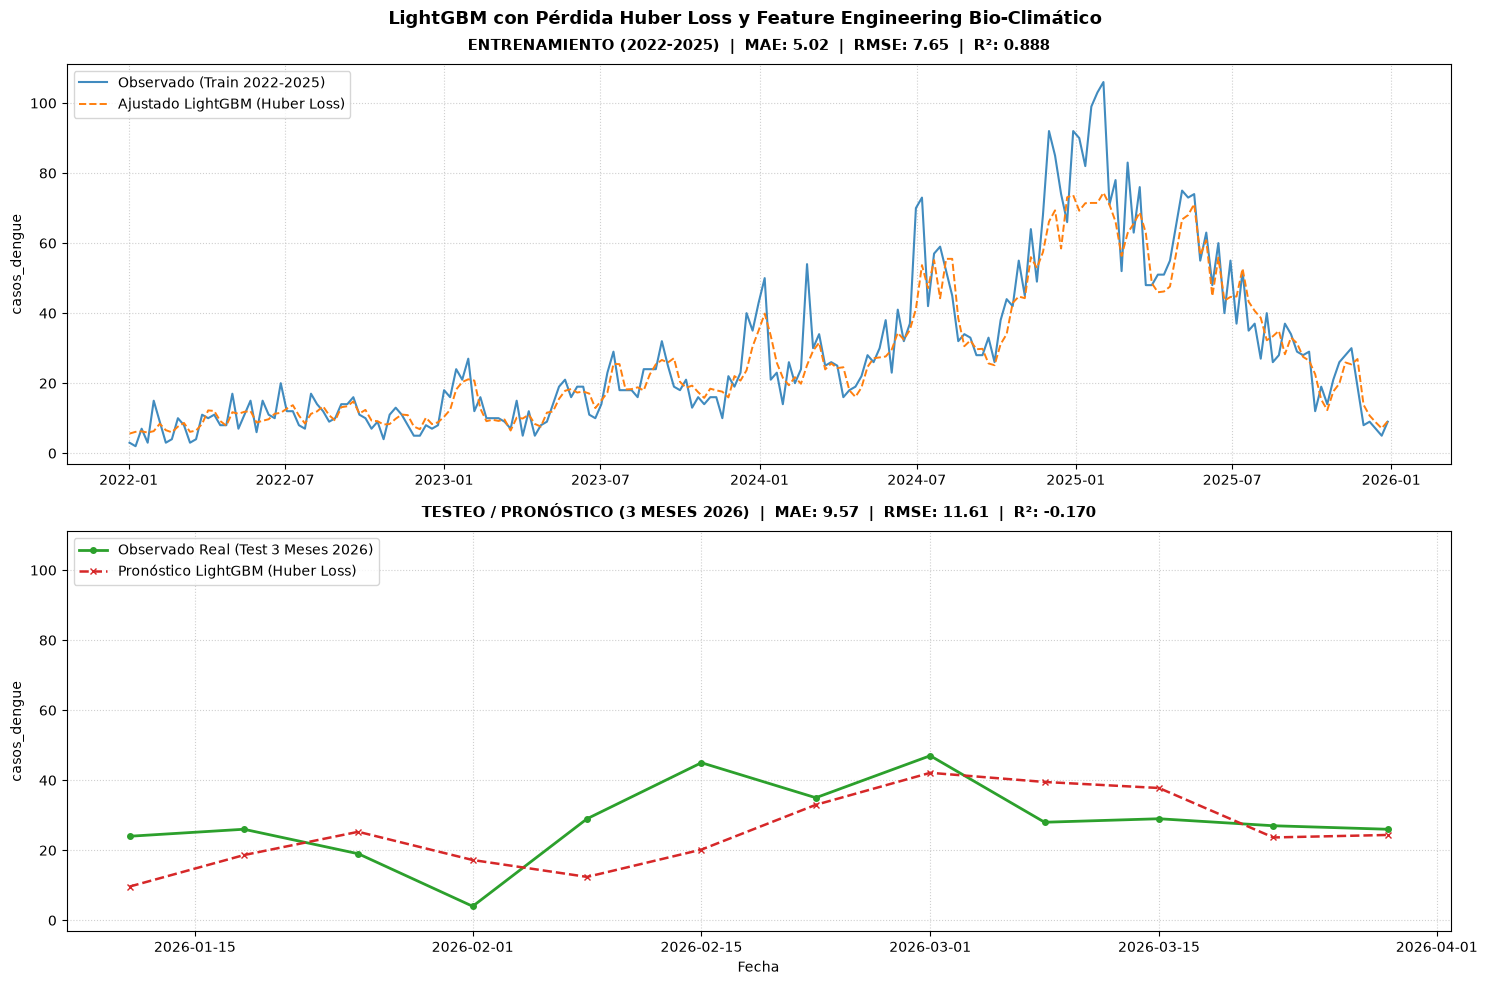


     CUADRO COMPARATIVO DE DESEMPEÑO (MODELO CON HUBER LOSS)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 5.024694  7.649376  0.888498
    Testeo (3 Meses 2026)       12 9.567794 11.610083 -0.170214

  TOP 20 ATRIBUTOS MÁS RELEVANTES (MODELO CON HUBER LOSS)  
          Atributo  Importancia_Gain  Porcentaje_Aporte_%
casos_dengue_lag_1       2851.462227            63.783120
casos_dengue_lag_2       1207.884257            27.018638
           hum_esp        137.022182             3.064990
         soi_lag_8        134.672761             3.012436
     vel_vi_lag_10         73.501686             1.644127
         soi_lag_6         66.016254             1.476689


In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS Y INGENIERÍA BIO-CLIMÁTICA
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad y Aceleración Epidémica ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 2. Tendencia y Medias Móviles de Casos ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 3. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# --- 4. NUEVA INGENIERÍA DE ATRIBUTOS CLIMÁTICOS (ESTRATEGIA B) ---
# Identificar columnas de lluvia / precipitación y temperatura
col_precip = [c for c in df.columns if any(p in c.lower() for p in ['lluvia', 'precip', 'pp'])]
col_temp = [c for c in df.columns if any(t in c.lower() for t in ['temp', 'tmedia', 'tmax', 'tmin'])]

# Acumulados de Lluvia (Ventanas de 2, 3 y 4 semanas para reproducción vectorial)
if len(col_precip) > 0:
    target_p = col_precip[0]
    df['lluvia_acumulada_2w'] = df[target_p].rolling(window=2, min_periods=1).sum()
    df['lluvia_acumulada_3w'] = df[target_p].rolling(window=3, min_periods=1).sum()
    df['lluvia_acumulada_4w'] = df[target_p].rolling(window=4, min_periods=1).sum()

# Umbrales Óptimos de Temperatura (22°C - 32°C para incubación biológica)
if len(col_temp) > 0:
    target_t = col_temp[0]
    df['temp_rango_optimo'] = ((df[target_t] >= 22.0) & (df[target_t] <= 32.0)).astype(int)
    df['temp_estres_termico'] = (df[target_t] > 32.0).astype(int)

# Limpieza de nulos generados por ventanas móviles
df = df.dropna()

# =============================================================================
# PASO 3: RECORTE TEMPORAL (ENTRENAMIENTO: 2022-2025 | TESTEO: 3 MESES DE 2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)

df_2026 = df[df.index.year >= 2026]
mask_test = df.index.isin(df_2026.iloc[:12].index)

y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_raw = df.drop(columns=['casos_dengue'])

X_train_raw, y_train_log = X_raw[mask_train], y_log[mask_train]
X_test_raw, y_test_log = X_raw[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]

# =============================================================================
# PASO 4: REDUCCIÓN DIMENSIONAL EN 2 ETAPAS (CORRELACIÓN + RFECV TEMPORAL)
# =============================================================================
print("\n" + "="*80)
print("   PASO 4A: FILTRADO DE MULTICOLINEALIDAD (|r| > 0.80) INCLUYENDO BIO-FEATURES   ")
print("="*80)

corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos',
    'lluvia_acumulada_3w', 'temp_rango_optimo'
]

to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_e1 = X_train_raw.drop(columns=to_drop_corr)
X_test_e1 = X_test_raw.drop(columns=to_drop_corr)

print(f"[INFO] Atributos iniciales: {X_train_raw.shape[1]}")
print(f"[INFO] Atributos descartados por correlación alta: {len(to_drop_corr)}")
print(f"[INFO] Atributos restantes tras Etapa 1: {X_train_e1.shape[1]}")

print("\n" + "="*80)
print("   PASO 4B: ELIMINACIÓN RECURSIVA RFECV CON OBJETIVO HUBER   ")
print("="*80)

# Evaluador RFECV configurado con Huber Loss
modelo_base_rfecv = lgb.LGBMRegressor(
    objective='huber',
    alpha=1.0,
    n_estimators=150,
    learning_rate=0.02,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

tscv = TimeSeriesSplit(n_splits=5)

rfecv = RFECV(
    estimator=modelo_base_rfecv,
    step=1,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    min_features_to_select=5
)

rfecv.fit(X_train_e1, y_train_log)

atributos_seleccionados = list(X_train_e1.columns[rfecv.support_])

X_train = X_train_e1[atributos_seleccionados]
X_test = X_test_e1[atributos_seleccionados]

print(f"[INFO] Atributos finales seleccionados por RFECV: {len(atributos_seleccionados)}")
print("="*80 + "\n")

# Exportar lista completa de atributos retenidos
df_seleccionados_export = pd.DataFrame({
    'Nro': range(1, len(atributos_seleccionados) + 1),
    'Atributo_Seleccionado': atributos_seleccionados,
    'Estado': 'Retenido tras Reducción Huber + BioFeatures'
})

ruta_excel_seleccionados = os.path.join(carpeta_resultados, "atributos_seleccionados_huber.xlsx")
df_seleccionados_export.to_excel(ruta_excel_seleccionados, index=False)


# =============================================================================
# PASO 5: OPTIMIZACIÓN CON OPTUNA (OBJETIVO HUBER LOSS)
# =============================================================================
def objective(trial):
    params = {
        'objective': 'huber',
        'alpha': trial.suggest_float('alpha', 0.5, 3.0),  # Parámetro de transición de Huber
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 450),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros con función de pérdida Huber...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'huber'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'huber',
        'alpha': 1.2,
        'metric': 'mae',
        'n_estimators': 300,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }

modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)


# =============================================================================
# PASO 6: PREDICCIONES Y MÉTRICAS
# =============================================================================
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 7: EXPORTACIÓN DE TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_huber.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Archivos guardados en:\n -> {ruta_excel_seleccionados}\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM (Huber Loss)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 3 Meses 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=4)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM (Huber Loss)', color='#d62728', linestyle='--', linewidth=1.8, marker='x', markersize=5)
axes[1].set_title(f"TESTEO / PRONÓSTICO (3 MESES 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('LightGBM con Pérdida Huber Loss y Feature Engineering Bio-Climático', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_huber.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (3 Meses 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (MODELO CON HUBER LOSS)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (MODELO CON HUBER LOSS)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

   PASO 4A: ETAPA 1 DE REDUCCIÓN - FILTRADO DE MULTICOLINEALIDAD (|r| > 0.80)   
[INFO] Atributos iniciales: 175
[INFO] Atributos descartados por alta correlación: 78
[INFO] Atributos restantes tras Etapa 1: 97

   PASO 4B: ETAPA 2 DE REDUCCIÓN - ELIMINACIÓN RECURSIVA CON TIMESERIES SPLIT   
[INFO] Atributos finales seleccionados por RFECV: 5

[EXPORTACIÓN EXITOSA] Lista de atributos seleccionados exportada a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\atributos_seleccionados_reduccion_dimensional.xlsx


[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_modelo_final.xlsx


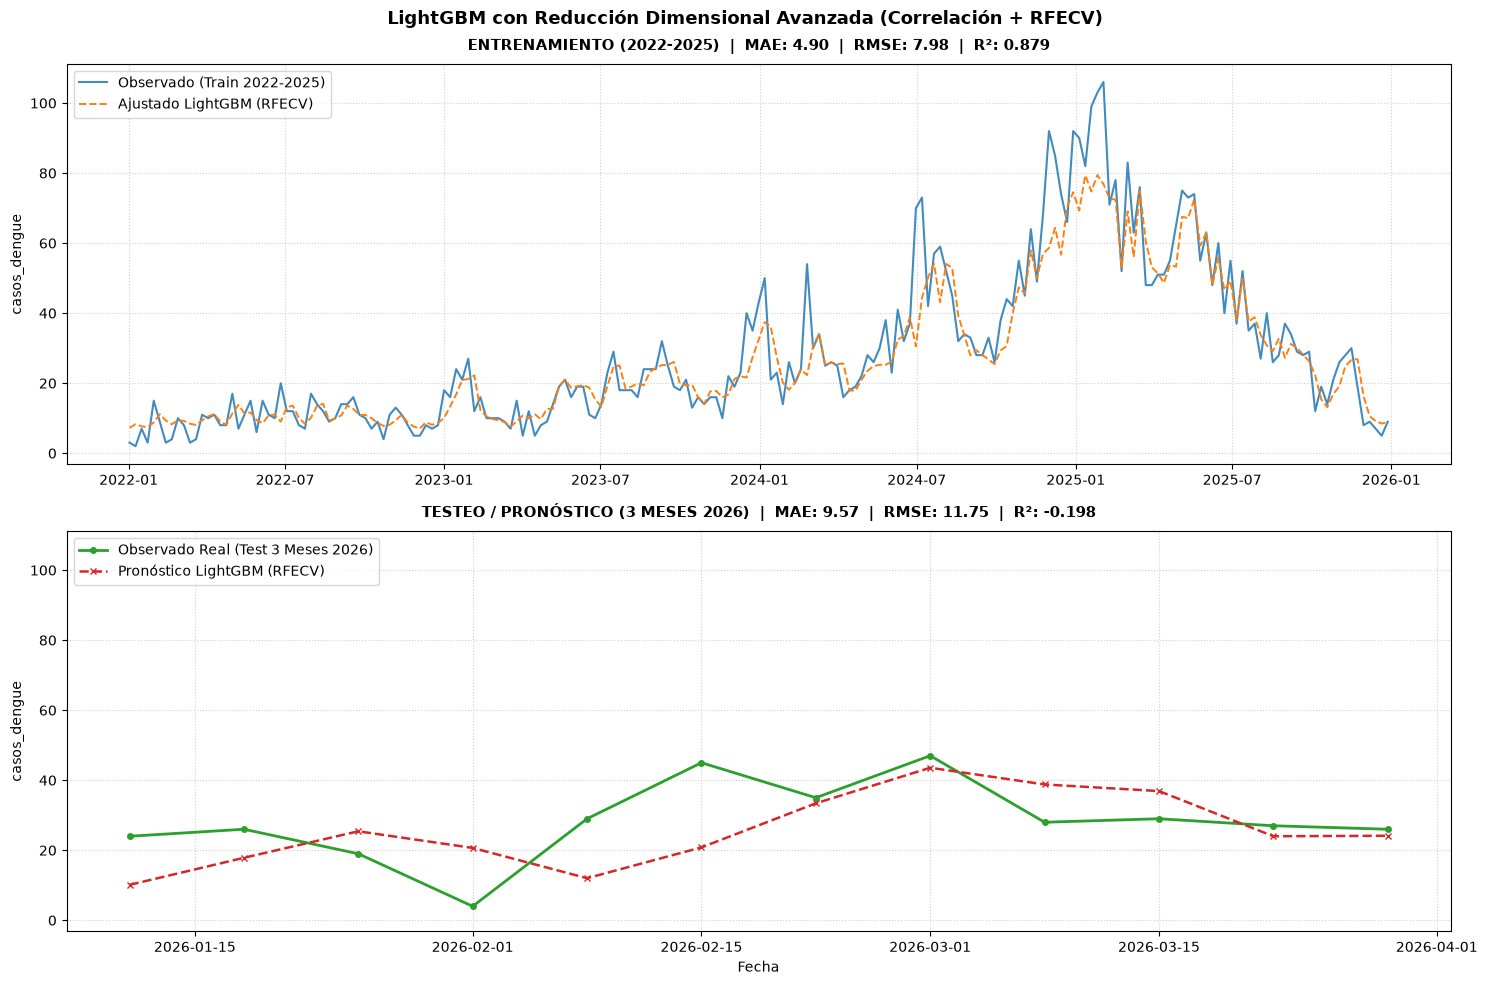


     CUADRO COMPARATIVO DE DESEMPEÑO (REDUCCIÓN AVANZADA RFECV)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 4.898965  7.978614  0.878693
    Testeo (3 Meses 2026)       12 9.571208 11.749244 -0.198435

  LISTA DE ATRIBUTOS RETENIDOS TRAS LA REDUCCIÓN DIMENSIONAL  
 Nro Atributo_Seleccionado                              Estado
   1               hum_esp Retenido tras Reducción Dimensional
   2             soi_lag_6 Retenido tras Reducción Dimensional
   3             soi_lag_8 Retenido tras Reducción Dimensional
   4    casos_dengue_lag_1 Retenido tras Reducción Dimensional
   5    casos_dengue_lag_2 Retenido tras Reducción Dimensional


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS Y ESTACIONALES
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad y Aceleración ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 2. Tendencia y Medias Móviles ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 3. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza estricta de registros nulos generados por transformaciones
df = df.dropna()

# =============================================================================
# PASO 3: RECORTE TEMPORAL (ENTRENAMIENTO: 2022-2025 | TESTEO: 3 MESES DE 2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)

df_2026 = df[df.index.year >= 2026]
mask_test = df.index.isin(df_2026.iloc[:12].index)

y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_raw = df.drop(columns=['casos_dengue'])

X_train_raw, y_train_log = X_raw[mask_train], y_log[mask_train]
X_test_raw, y_test_log = X_raw[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]

# =============================================================================
# PASO 4: REDUCCIÓN DIMENSIONAL EN 2 ETAPAS (CORRELACIÓN + RFECV TEMPORAL)
# =============================================================================
print("\n" + "="*80)
print("   PASO 4A: ETAPA 1 DE REDUCCIÓN - FILTRADO DE MULTICOLINEALIDAD (|r| > 0.80)   ")
print("="*80)

# Etapa 1: Matriz de correlación de Spearman (|r| > 0.80)
corr_matrix = X_train_raw.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

UMBRAL_CORRELACION = 0.80
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos'
]

to_drop_corr = [col for col in to_drop_corr if col not in variables_protegidas]

X_train_e1 = X_train_raw.drop(columns=to_drop_corr)
X_test_e1 = X_test_raw.drop(columns=to_drop_corr)

print(f"[INFO] Atributos iniciales: {X_train_raw.shape[1]}")
print(f"[INFO] Atributos descartados por alta correlación: {len(to_drop_corr)}")
print(f"[INFO] Atributos restantes tras Etapa 1: {X_train_e1.shape[1]}")

# --- PASO 4B: ETAPA 2 - SELECCIÓN RECURSIVA CON VALIDACIÓN TEMPORAL (RFECV) ---
print("\n" + "="*80)
print("   PASO 4B: ETAPA 2 DE REDUCCIÓN - ELIMINACIÓN RECURSIVA CON TIMESERIES SPLIT   ")
print("="*80)

modelo_base_rfecv = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=150,
    learning_rate=0.02,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

# Validación cruzada temporal (5 cortes cronológicos)
tscv = TimeSeriesSplit(n_splits=5)

rfecv = RFECV(
    estimator=modelo_base_rfecv,
    step=1,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    min_features_to_select=5
)

rfecv.fit(X_train_e1, y_train_log)

# Atributos seleccionados tras RFECV
atributos_seleccionados = list(X_train_e1.columns[rfecv.support_])

X_train = X_train_e1[atributos_seleccionados]
X_test = X_test_e1[atributos_seleccionados]

print(f"[INFO] Atributos finales seleccionados por RFECV: {len(atributos_seleccionados)}")
print("="*80 + "\n")

# =============================================================================
# EXPORTACIÓN 1: EXCEL DE LISTA COMPLETA DE ATRIBUTOS SELECCIONADOS
# =============================================================================
df_seleccionados_export = pd.DataFrame({
    'Nro': range(1, len(atributos_seleccionados) + 1),
    'Atributo_Seleccionado': atributos_seleccionados,
    'Estado': 'Retenido tras Reducción Dimensional'
})

ruta_excel_seleccionados = os.path.join(carpeta_resultados, "atributos_seleccionados_reduccion_dimensional.xlsx")
df_seleccionados_export.to_excel(ruta_excel_seleccionados, index=False)

print(f"[EXPORTACIÓN EXITOSA] Lista de atributos seleccionados exportada a:\n -> {ruta_excel_seleccionados}\n")


# =============================================================================
# PASO 5: OPTIMIZACIÓN CON OPTUNA Y ENTRENAMIENTO LIGHTGBM
# =============================================================================
def objective(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 450),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros sobre el conjunto optimizado...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'regression_l1'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 300,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }

modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)


# =============================================================================
# PASO 6: PREDICCIONES Y REVERSIÓN A ESCALA REAL
# =============================================================================
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# EXPORTACIÓN 2: EXCEL TOP 20 ATRIBUTOS MÁS RELEVANTES DEL MODELO FINAL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_modelo_final.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM (RFECV)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 3 Meses 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=4)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM (RFECV)', color='#d62728', linestyle='--', linewidth=1.8, marker='x', markersize=5)
axes[1].set_title(f"TESTEO / PRONÓSTICO (3 MESES 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('LightGBM con Reducción Dimensional Avanzada (Correlación + RFECV)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_rfecv.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (3 Meses 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (REDUCCIÓN AVANZADA RFECV)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  LISTA DE ATRIBUTOS RETENIDOS TRAS LA REDUCCIÓN DIMENSIONAL  ")
print("="*80)
print(df_seleccionados_export.to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

     REDUCCIÓN DIMENSIONAL POR FILTRADO DE MULTICOLINEALIDAD (|r| > 0.85)     
[INFO] Atributos iniciales: 175
[INFO] Atributos redundantes eliminados: 72
[INFO] Atributos retenidos para el modelo: 103
[INFO] Filas Train (2022-2025): 209 | Filas Test (3 Meses 2026): 12


[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_sin_colinealidad.xlsx


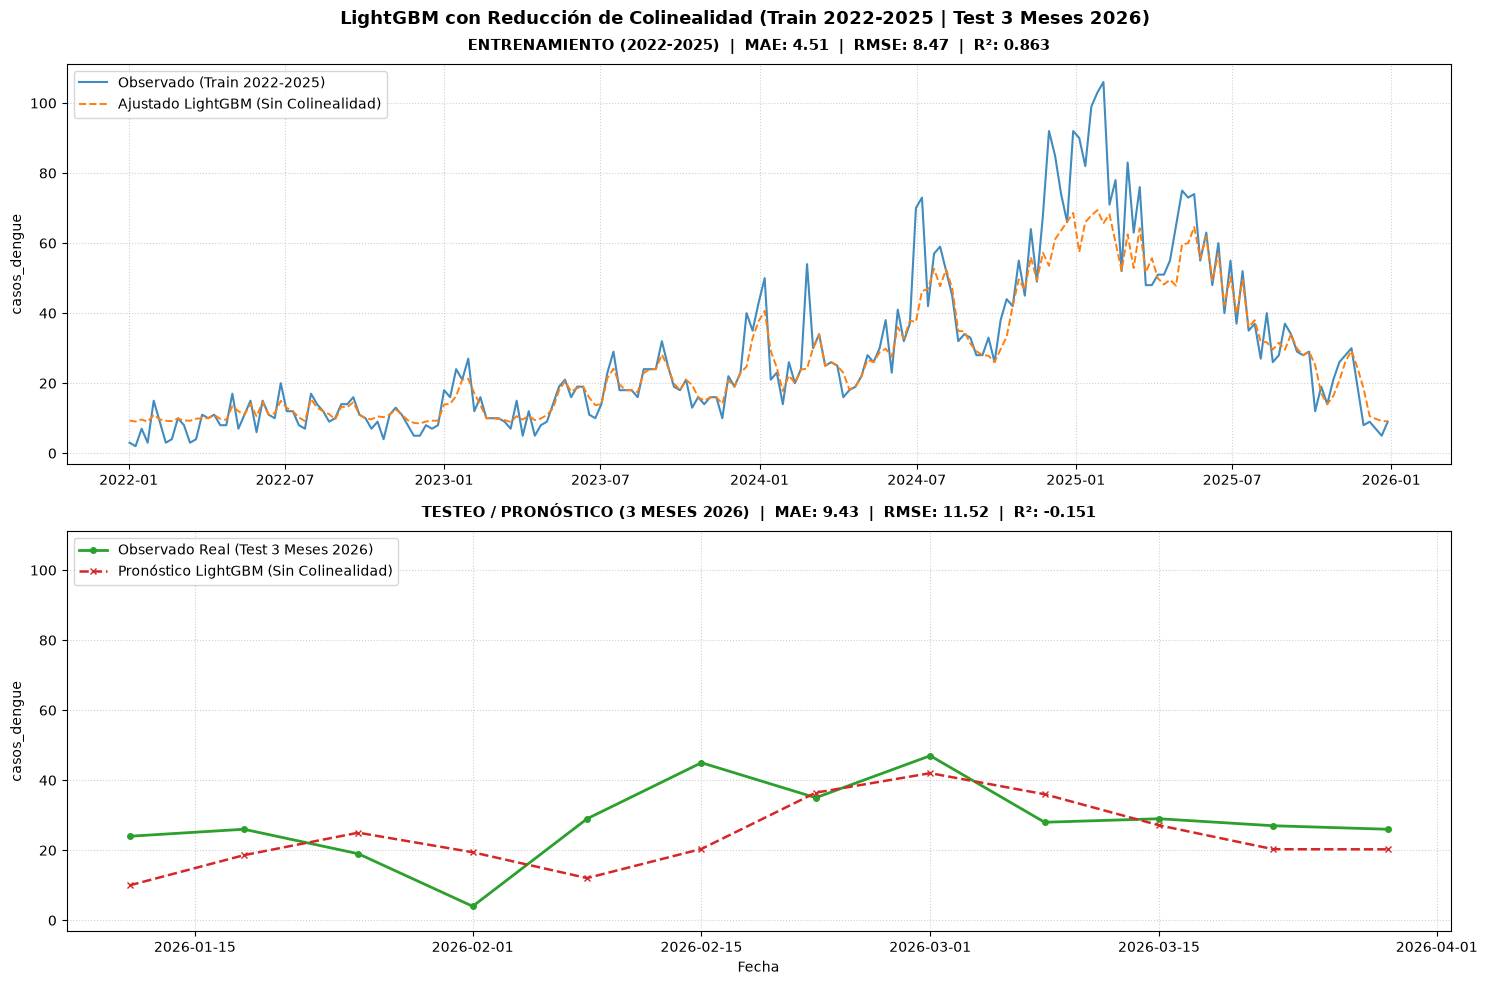


     CUADRO COMPARATIVO DE DESEMPEÑO (MATRIZ SIN MULTICOLINEALIDAD)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2022-2025)      209 4.505834  8.471649  0.863237
    Testeo (3 Meses 2026)       12 9.432060 11.516456 -0.151416

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
             Atributo  Importancia_Gain  Porcentaje_Aporte_%
   casos_dengue_lag_1       6094.593803            40.216458
   casos_dengue_lag_2       3949.440232            26.061212
            soi_lag_9        600.955314             3.965530
   casos_ma_4_semanas        493.344425             3.255437
         vel_vi_lag_4        445.640619             2.940653
              hum_esp        392.434590             2.589562
            soi_lag_6        360.977969             2.381989
       temp_min_lag_3        319.387609             2.107546
           prec_lag_7        256.821260             1.694689
           soi_lag_12        238.811361             1.575847
     

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS Y ESTACIONALES
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad de transmisión ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)

# --- 2. Aceleración epidémica ---
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 3. Tendencia y Medias Móviles ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 4. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza estricta de registros nulos generados por transformaciones
df = df.dropna()

# =============================================================================
# PASO 3: RECORTE TEMPORAL (ENTRENAMIENTO: 2022-2025 | TESTEO: 3 MESES DE 2026)
# =============================================================================
df = df[df.index.year >= 2022]

mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)

df_2026 = df[df.index.year >= 2026]
mask_test = df.index.isin(df_2026.iloc[:12].index)

y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_raw = df.drop(columns=['casos_dengue'])

X_train_raw, y_train_log = X_raw[mask_train], y_log[mask_train]
X_test_raw, y_test_log = X_raw[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]


# =============================================================================
# PASO 4: REDUCCIÓN DIMENSIONAL POR FILTRADO DE COLINEALIDAD CRÍTICA
# =============================================================================
# Matriz de correlación de Spearman sobre los datos de entrenamiento
corr_matrix = X_train_raw.corr(method='spearman').abs()

# Seleccionar la parte superior de la matriz de correlación
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Umbral estricto de correlación
UMBRAL_CORRELACION = 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > UMBRAL_CORRELACION)]

# Excluir de la eliminación las variables estructurales indispensables
variables_protegidas = [
    col_lag1, col_lag2, 'velocidad_epidemica', 'aceleracion_epidemica', 
    'casos_ma_4_semanas', 'desviacion_media_4s', 'mes_sin', 'mes_cos'
]

to_drop = [col for col in to_drop if col not in variables_protegidas]

# Filtrar matrices de atributos
X_train = X_train_raw.drop(columns=to_drop)
X_test = X_test_raw.drop(columns=to_drop)

print("\n" + "="*80)
print("     REDUCCIÓN DIMENSIONAL POR FILTRADO DE MULTICOLINEALIDAD (|r| > 0.85)     ")
print("="*80)
print(f"[INFO] Atributos iniciales: {X_train_raw.shape[1]}")
print(f"[INFO] Atributos redundantes eliminados: {len(to_drop)}")
print(f"[INFO] Atributos retenidos para el modelo: {X_train.shape[1]}")
print(f"[INFO] Filas Train (2022-2025): {len(X_train)} | Filas Test (3 Meses 2026): {len(X_test)}")
print("="*80 + "\n")


# =============================================================================
# PASO 5: OPTIMIZACIÓN CON OPTUNA Y ENTRENAMIENTO LIGHTGBM
# =============================================================================
def objective(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 450),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros sobre la matriz sin colinealidad...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'regression_l1'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 300,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }

modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)


# =============================================================================
# PASO 6: PREDICCIONES Y REVERSIÓN A ESCALA REAL
# =============================================================================
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

# Reversión de la escala logarítmica expm1(y)
y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

# Métricas de Evaluación
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 7: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_sin_colinealidad.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento (2022-2025)
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM (Sin Colinealidad)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo (Primeros 3 meses de 2026)
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 3 Meses 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=4)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM (Sin Colinealidad)', color='#d62728', linestyle='--', linewidth=1.8, marker='x', markersize=5)
axes[1].set_title(f"TESTEO / PRONÓSTICO (3 MESES 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('LightGBM con Reducción de Colinealidad (Train 2022-2025 | Test 3 Meses 2026)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_sin_colinealidad.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 9: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (3 Meses 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (MATRIZ SIN MULTICOLINEALIDAD)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

   CONFIGURACIÓN DE VENTANAS: TRAIN (2022-2025) | TEST (3 MESES / 12 SEMANAS DE 2026)   
[INFO] Observaciones Train (2022-2025): 209 semanas
[INFO] Observaciones Test (3 Meses 2026): 12 semanas
[INFO] Rango de fechas Test: 2026-01-11 a 2026-03-29


[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_2022_2026_3meses.xlsx


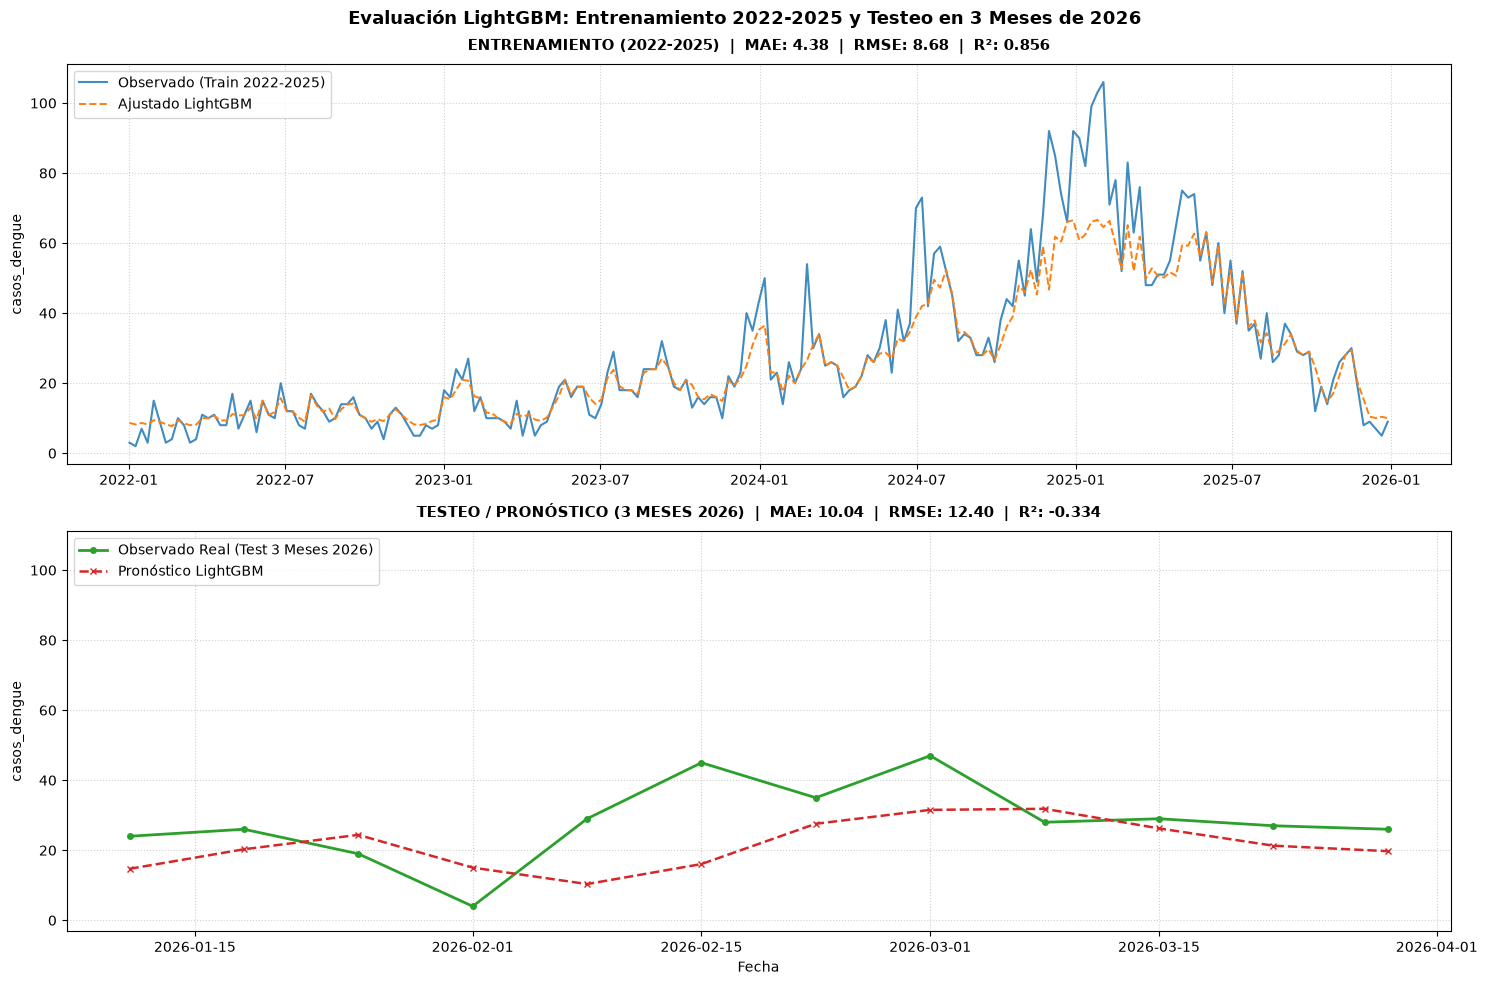


     CUADRO COMPARATIVO DE DESEMPEÑO (TRAIN 2022-2025 | TEST 3 MESES)     
                     Fase  Semanas       MAE      RMSE        R²
Entrenamiento (2022-2025)      209  4.376897  8.682048  0.856360
    Testeo (3 Meses 2026)       12 10.042547 12.396422 -0.334097

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
             Atributo  Importancia_Gain  Porcentaje_Aporte_%
   casos_dengue_lag_1       6027.443798            43.237249
   casos_dengue_lag_2       2829.408197            20.296469
   casos_dengue_lag_8        547.453966             3.927105
     vel_vi_max_lag_4        482.396687             3.460423
            soi_lag_6        461.676572             3.311789
   casos_dengue_lag_4        351.591069             2.522102
   casos_ma_4_semanas        297.258545             2.132354
            soi_lag_9        275.645189             1.977312
           prec_lag_7        273.640150             1.962930
   casos_dengue_lag_3        264.626238             1.898269


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS DE VELOCIDAD Y ACELERACIÓN
# =============================================================================
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad de transmisión ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)

# --- 2. Aceleración epidémica ---
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 3. Tendencia y Medias Móviles ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 4. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza estricta de registros nulos generados por transformaciones
df = df.dropna()

# =============================================================================
# PASO 3: RECORTE TEMPORAL (ENTRENAMIENTO: 2022-2025 | TESTEO: 3 MESES / 12 SEMANAS DE 2026)
# =============================================================================
# 1. Filtrar para iniciar únicamente desde el año 2022
df = df[df.index.year >= 2022]

# 2. Definir máscaras de entrenamiento y testeo
mask_train = (df.index.year >= 2022) & (df.index.year <= 2025)

# Obtener los primeros 3 meses de 2026 (primeras 12 semanas)
df_2026 = df[df.index.year >= 2026]
mask_test = df.index.isin(df_2026.iloc[:12].index)

# Transformación logarítmica log(y + 1)
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_features = df.drop(columns=['casos_dengue'])

X_train, y_train_log = X_features[mask_train], y_log[mask_train]
X_test, y_test_log = X_features[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]

print("\n" + "="*75)
print("   CONFIGURACIÓN DE VENTANAS: TRAIN (2022-2025) | TEST (3 MESES / 12 SEMANAS DE 2026)   ")
print("="*75)
print(f"[INFO] Observaciones Train (2022-2025): {len(X_train)} semanas")
print(f"[INFO] Observaciones Test (3 Meses 2026): {len(X_test)} semanas")
print(f"[INFO] Rango de fechas Test: {X_test.index.min().strftime('%Y-%m-%d')} a {X_test.index.max().strftime('%Y-%m-%d')}")
print("="*75 + "\n")


# =============================================================================
# PASO 4: OPTIMIZACIÓN CON OPTUNA Y ENTRENAMIENTO LIGHTGBM
# =============================================================================
def objective(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 450),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros sobre la ventana 2022-2025...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'regression_l1'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 300,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }

modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)


# =============================================================================
# PASO 5: PREDICCIONES Y REVERSIÓN A ESCALA REAL
# =============================================================================
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

# Reversión de la escala logarítmica expm1(y)
y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

# Métricas de Evaluación
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 6: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_features.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_2022_2026_3meses.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 7: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento (2022-2025)
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2022-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2022-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo (Primeros 3 meses de 2026)
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 3 Meses 2026)', color='#2ca02c', linewidth=2.0, marker='o', markersize=4)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM', color='#d62728', linestyle='--', linewidth=1.8, marker='x', markersize=5)
axes[1].set_title(f"TESTEO / PRONÓSTICO (3 MESES 2026)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Evaluación LightGBM: Entrenamiento 2022-2025 y Testeo en 3 Meses de 2026', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_2022_2026_3meses.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 8: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2022-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (3 Meses 2026)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (TRAIN 2022-2025 | TEST 3 MESES)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

     MATRIZ CON ATRIBUTOS DINÁMICOS (VELOCIDAD Y ACELERACIÓN)     
[INFO] Rango completo: 2021-04-04 a 2026-05-31
[INFO] Total observaciones válidas: 269
[INFO] Atributos predictores totales (incluyendo dinámicos): 175


[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_dinamicos_lightgbm.xlsx


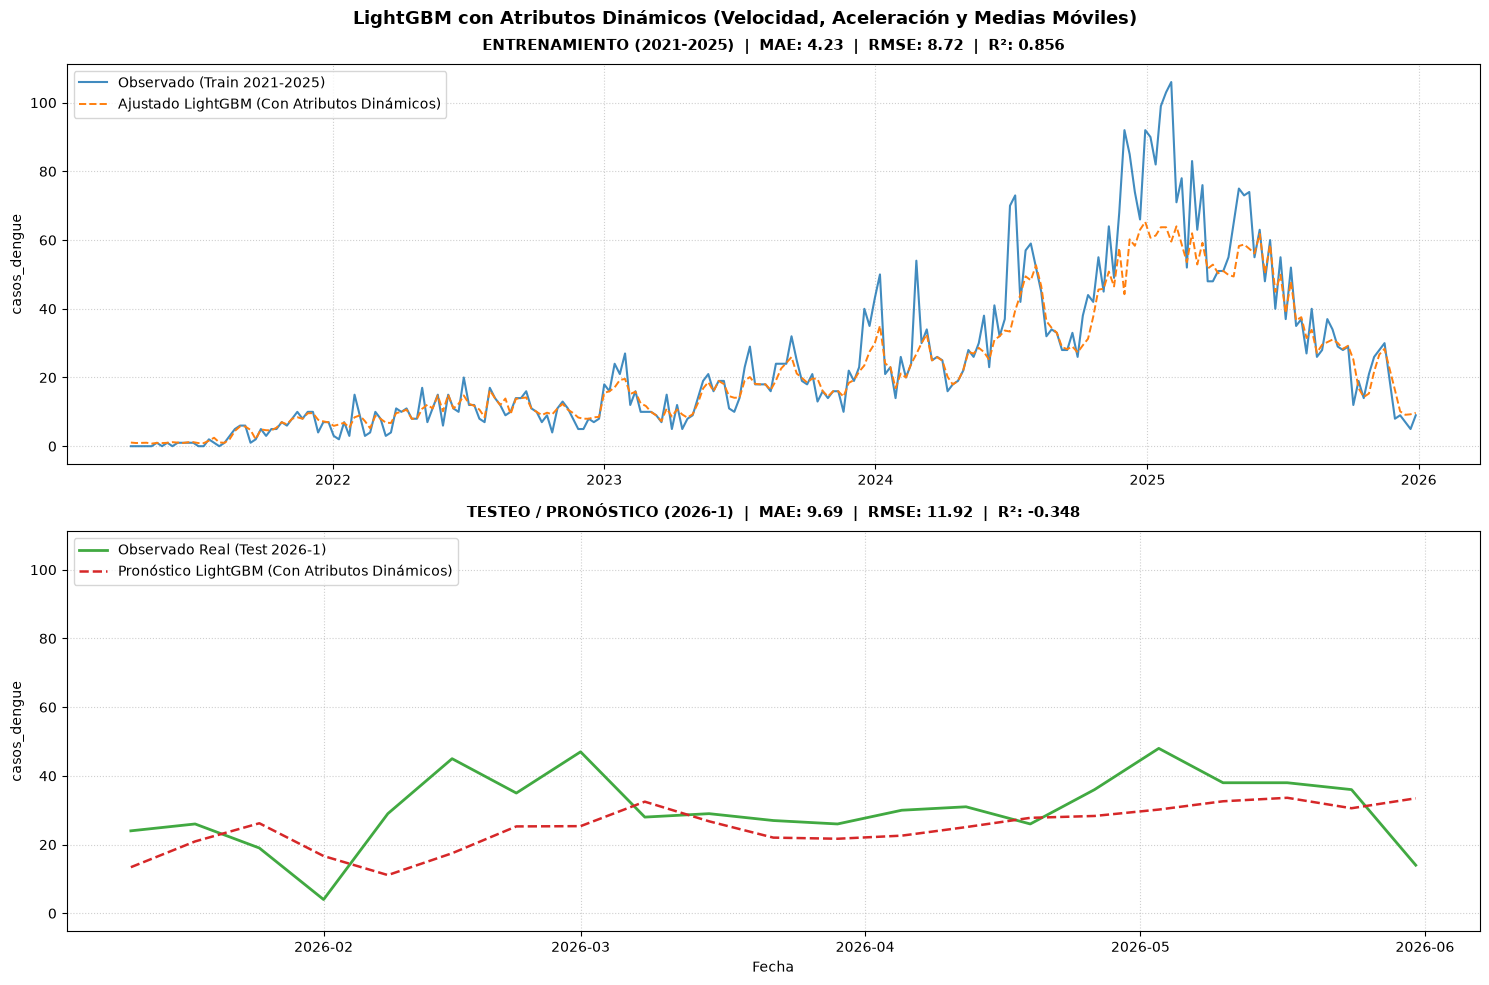


     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM + ATRIBUTOS DINÁMICOS)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2021-2025)      248 4.227265  8.720607  0.856261
          Testeo (2026-1)       21 9.692168 11.920695 -0.347686

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
             Atributo  Importancia_Gain  Porcentaje_Aporte_%
   casos_dengue_lag_1       9324.897076            43.342819
   casos_dengue_lag_2       4874.793310            22.658404
   casos_dengue_lag_8        864.194707             4.016842
   casos_ma_4_semanas        845.408986             3.929524
   casos_dengue_lag_3        602.141720             2.798800
   casos_dengue_lag_4        582.150168             2.705878
     vel_vi_max_lag_4        567.674813             2.638595
  casos_dengue_lag_10        520.007579             2.417034
            soi_lag_6        494.045331             2.296360
       temp_max_lag_4        349.610830             1.625017
   

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: CREACIÓN DE ATRIBUTOS DINÁMICOS DE VELOCIDAD Y ACELERACIÓN
# =============================================================================
# Búsqueda o selección de la variable de casuística rezagada principal
col_lag1 = None
col_lag2 = None

for col in df.columns:
    if 'casos' in col.lower() and ('lag_1' in col.lower() or 'rezago_1' in col.lower()):
        col_lag1 = col
    elif 'casos' in col.lower() and ('lag_2' in col.lower() or 'rezago_2' in col.lower()):
        col_lag2 = col

# Si no existen variables de rezago explícitas con esa nomenclatura, se generan
if col_lag1 is None:
    df['casos_lag_1'] = df['casos_dengue'].shift(1)
    col_lag1 = 'casos_lag_1'
if col_lag2 is None:
    df['casos_lag_2'] = df['casos_dengue'].shift(2)
    col_lag2 = 'casos_lag_2'

# --- 1. Velocidad de transmisión (Razón de Cambio Relativa) ---
df['velocidad_epidemica'] = (df[col_lag1] + 1) / (df[col_lag2] + 1)

# --- 2. Aceleración epidémica (Variación de la Velocidad) ---
df['aceleracion_epidemica'] = df['velocidad_epidemica'] - df['velocidad_epidemica'].shift(1)

# --- 3. Tendencia y Medias Móviles de Casos ---
df['casos_ma_4_semanas'] = df[col_lag1].rolling(window=4, min_periods=1).mean()
df['desviacion_media_4s'] = df[col_lag1] - df['casos_ma_4_semanas']

# --- 4. Componentes Estacionales ---
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza estricta de registros nulos generados por las transformaciones dinámicas
df = df.dropna()

# Variable Objetivo y Transformación Logarítmica
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_features = df.drop(columns=['casos_dengue'])

print("\n" + "="*75)
print("     MATRIZ CON ATRIBUTOS DINÁMICOS (VELOCIDAD Y ACELERACIÓN)     ")
print("="*75)
print(f"[INFO] Rango completo: {df.index.min().strftime('%Y-%m-%d')} a {df.index.max().strftime('%Y-%m-%d')}")
print(f"[INFO] Total observaciones válidas: {len(df)}")
print(f"[INFO] Atributos predictores totales (incluyendo dinámicos): {X_features.shape[1]}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train, y_train_log = X_features[mask_train], y_log[mask_train]
X_test, y_test_log = X_features[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]


# =============================================================================
# PASO 4: OPTIMIZACIÓN CON OPTUNA Y ENTRENAMIENTO LIGHTGBM
# =============================================================================
def objective(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros con el nuevo conjunto dinámico de atributos...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'regression_l1'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 350,
        'learning_rate': 0.01,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }

modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)


# =============================================================================
# PASO 5: PREDICCIONES Y REVERSIÓN A ESCALA REAL
# =============================================================================
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

# Transformación Inversa expm1(y)
y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

# Métricas de Evaluación
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 6: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_features.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_dinamicos_lightgbm.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 7: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM (Con Atributos Dinámicos)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM (Con Atributos Dinámicos)', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('LightGBM con Atributos Dinámicos (Velocidad, Aceleración y Medias Móviles)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_train_test_atributos_dinamicos.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 8: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM + ATRIBUTOS DINÁMICOS)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros pre-configurados.

             INICIANDO MODELO ENSAMBLE HÍBRIDO (LGBM + RIDGE)            
[INFO] Peso óptimo asignado a LightGBM: 1.000
[INFO] Peso óptimo asignado a Ridge: 0.000

[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_ensamble_hibrido.xlsx


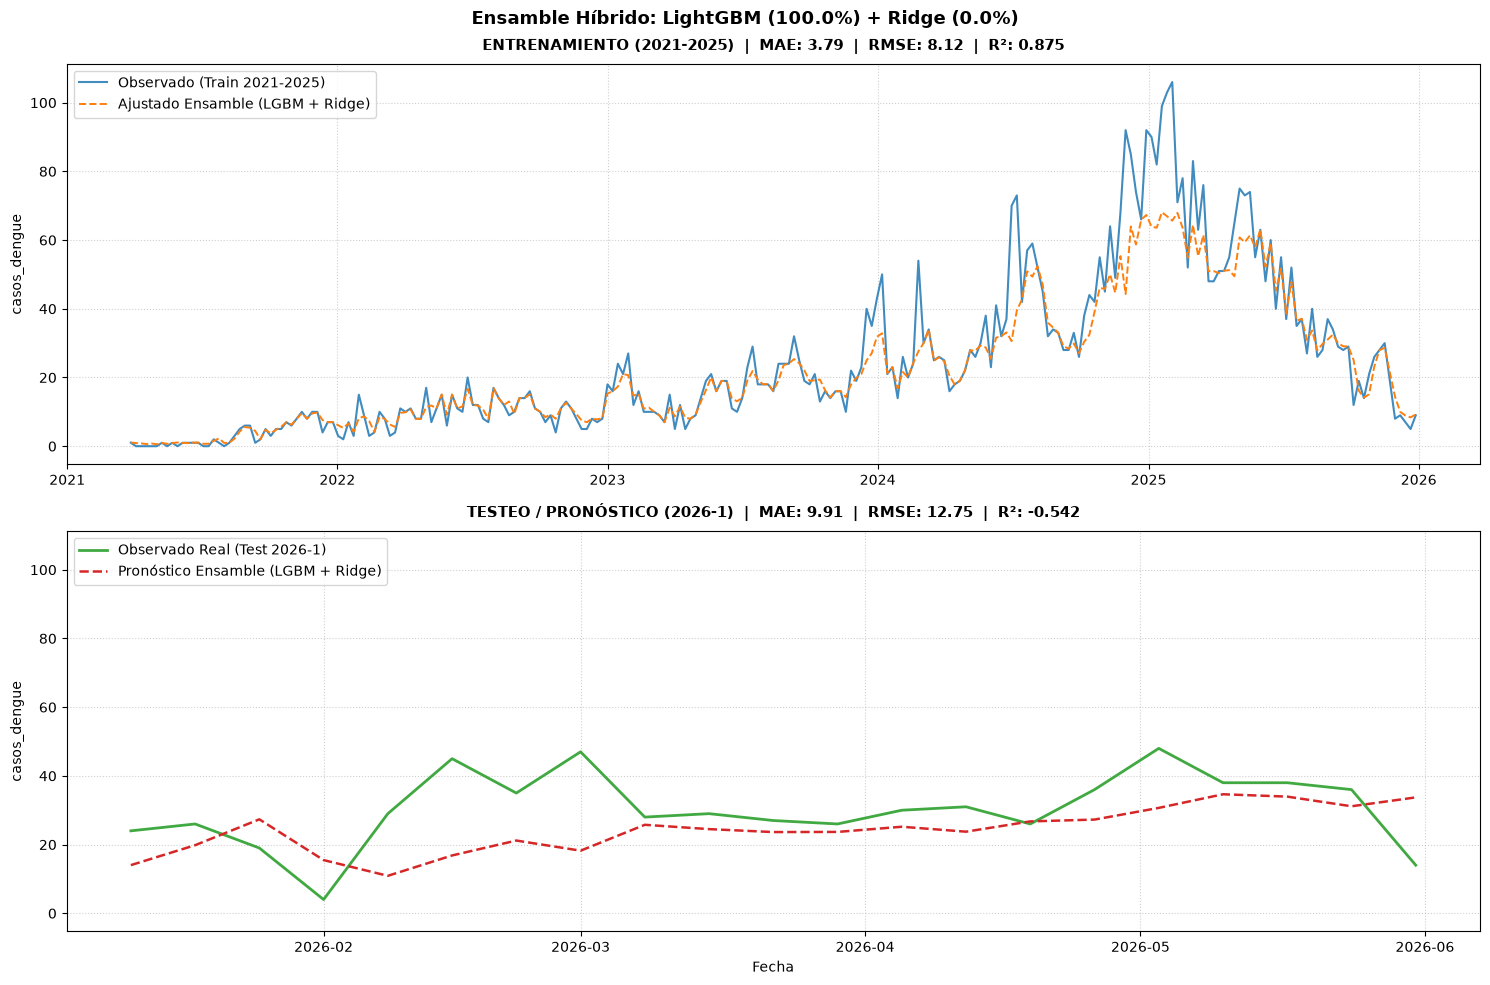


     CUADRO COMPARATIVO DE DESEMPEÑO (ENSAMBLE HÍBRIDO)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2021-2025)      249 3.794333  8.120494  0.875389
          Testeo (2026-1)       21 9.909435 12.750670 -0.541884

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
           Atributo  Importancia_Gain_LGBM  Porcentaje_Aporte_%
 casos_dengue_lag_1            7200.744511            46.201570
 casos_dengue_lag_2            2952.682478            18.945064
 casos_dengue_lag_8             771.883976             4.952578
 casos_dengue_lag_4             449.967519             2.887091
 casos_dengue_lag_3             409.938759             2.630258
     temp_max_lag_4             383.974623             2.463666
   vel_vi_max_lag_4             379.555682             2.435313
          soi_lag_6             370.189581             2.375218
casos_dengue_lag_10             299.075198             1.918933
            hum_rel             280.978300      

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: COMPONENTES ESTACIONALES Y MATRIZ DE CARACTERÍSTICAS
# =============================================================================
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

df = df.dropna()

# Aplicar transformación logarítmica log(y + 1) a la variable respuesta
y_real = df['casos_dengue']
y_log = np.log1p(y_real)

X_features = df.drop(columns=['casos_dengue'])

# =============================================================================
# PASO 3: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train, y_train_log = X_features[mask_train], y_log[mask_train]
X_test, y_test_log = X_features[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]

print("\n" + "="*75)
print("             INICIANDO MODELO ENSAMBLE HÍBRIDO (LGBM + RIDGE)            ")
print("="*75)


# =============================================================================
# PASO 4: MODELO 1 - LIGHTGBM
# =============================================================================
params_lgb = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'n_estimators': 300,
    'learning_rate': 0.015,
    'max_depth': 3,
    'num_leaves': 7,
    'min_child_samples': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.5,
    'reg_lambda': 1.5,
    'random_state': 42,
    'verbosity': -1
}

modelo_lgb = lgb.LGBMRegressor(**params_lgb)
modelo_lgb.fit(X_train, y_train_log)

pred_lgb_train_log = modelo_lgb.predict(X_train)
pred_lgb_test_log = modelo_lgb.predict(X_test)


# =============================================================================
# PASO 5: MODELO 2 - RIDGE REGRESSION (REGULARIZACIÓN LINEAL)
# =============================================================================
# Normalizar características para el modelo lineal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_ridge = RidgeCV(alphas=np.logspace(-3, 3, 50))
modelo_ridge.fit(X_train_scaled, y_train_log)

pred_ridge_train_log = modelo_ridge.predict(X_train_scaled)
pred_ridge_test_log = modelo_ridge.predict(X_test_scaled)


# =============================================================================
# PASO 6: OPTIMIZACIÓN DEL PESO DEL ENSAMBLE (PONDERACIÓN ÓPTIMA)
# =============================================================================
def func_perdida(peso):
    w = peso[0]
    pred_ensamble_log = w * pred_lgb_train_log + (1 - w) * pred_ridge_train_log
    pred_real = np.expm1(pred_ensamble_log)
    return mean_absolute_error(y_train_real, pred_real)

# Encontrar el peso óptimo w en Entrenamiento
res = minimize(func_perdida, x0=[0.5], bounds=[(0, 1)], method='L-BFGS-B')
w_optimo = res.x[0]

print(f"[INFO] Peso óptimo asignado a LightGBM: {w_optimo:.3f}")
print(f"[INFO] Peso óptimo asignado a Ridge: {1 - w_optimo:.3f}")


# =============================================================================
# PASO 7: PREDICCIONES DEL ENSAMBLE Y REVERSIÓN A ESCALA REAL
# =============================================================================
# Ensamble escala Log
y_train_pred_ens_log = w_optimo * pred_lgb_train_log + (1 - w_optimo) * pred_ridge_train_log
y_test_pred_ens_log = w_optimo * pred_lgb_test_log + (1 - w_optimo) * pred_ridge_test_log

# Reversión expm1(y)
y_train_pred = pd.Series(np.expm1(y_train_pred_ens_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_ens_log), index=y_test_real.index).clip(lower=0)

# Cálculo de Métricas en Escala Real
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 8: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_features.columns,
    'Importancia_Gain_LGBM': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain_LGBM', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain_LGBM'] / df_top20['Importancia_Gain_LGBM'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_ensamble_hibrido.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 9: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado Ensamble (LGBM + Ridge)', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico Ensamble (LGBM + Ridge)', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle(f'Ensamble Híbrido: LightGBM ({w_optimo*100:.1f}%) + Ridge ({(1-w_optimo)*100:.1f}%)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_train_test_ensamble_hibrido.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 10: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (ENSAMBLE HÍBRIDO)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain_LGBM', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.

     MATRIZ CON TRANSFORMACIÓN LOGARÍTMICA Y ESTACIONALIDAD     
[INFO] Rango completo: 2021-03-28 a 2026-05-31
[INFO] Total observaciones: 270
[INFO] Atributos predictores totales: 171


[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_lightgbm.xlsx


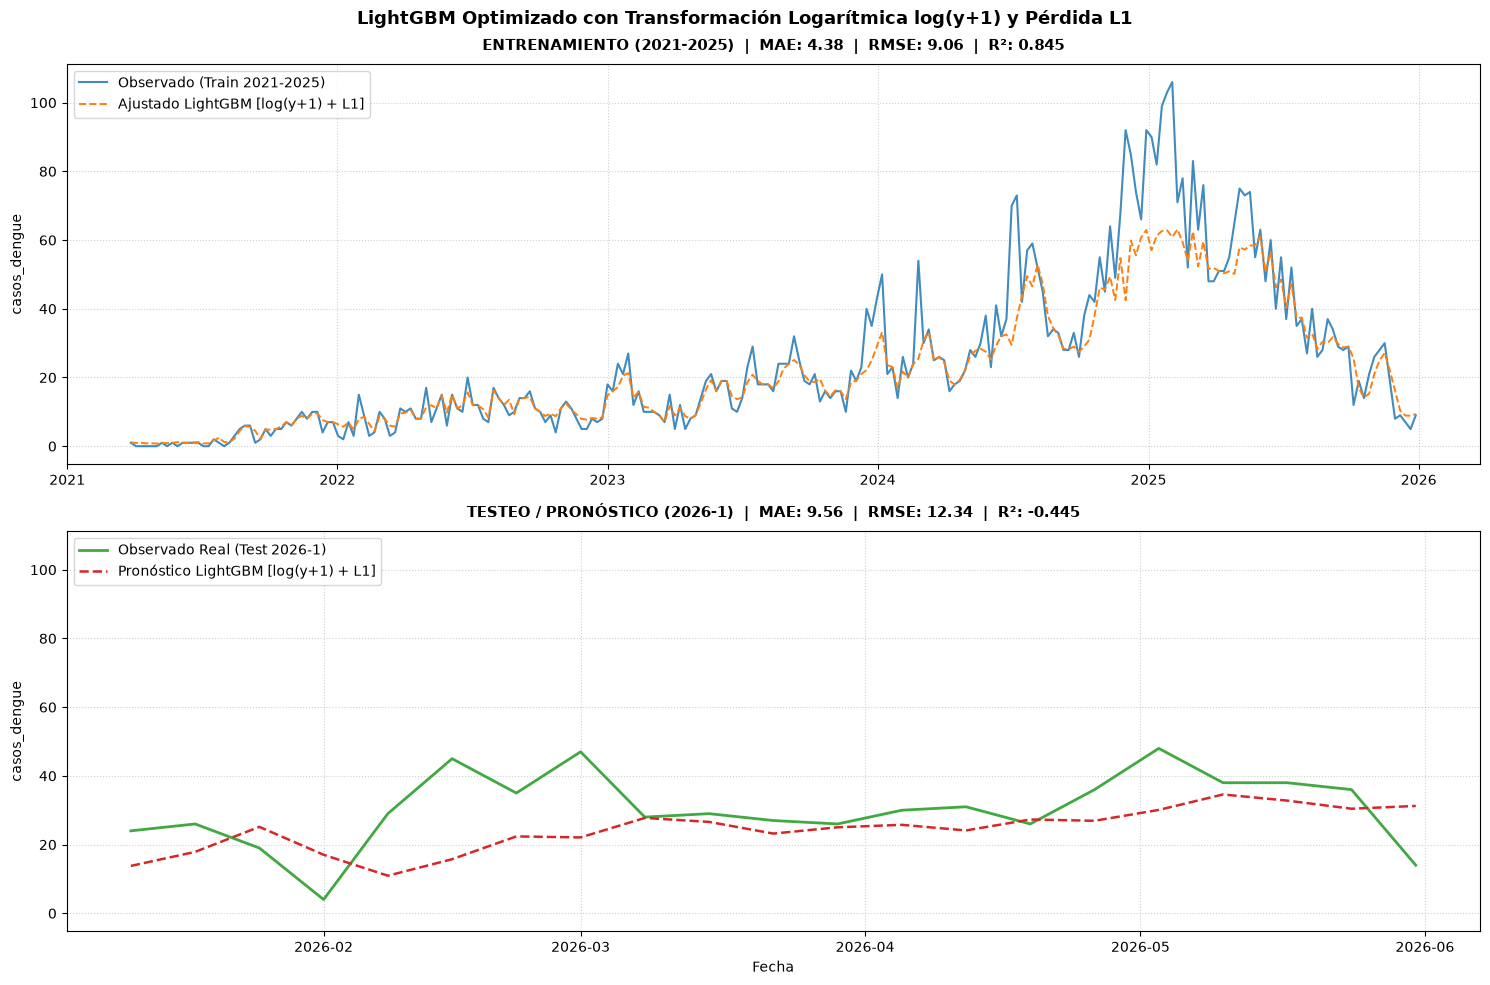


     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM LOG(Y+1) + L1)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2021-2025)      249 4.376976  9.064737  0.844725
          Testeo (2026-1)       21 9.555233 12.343151 -0.444900

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
           Atributo  Importancia_Gain  Porcentaje_Aporte_%
 casos_dengue_lag_1       9635.534567            44.918154
 casos_dengue_lag_2       4926.500596            22.965961
 casos_dengue_lag_8       1153.952275             5.379401
casos_dengue_lag_10        579.610550             2.701981
     temp_max_lag_4        516.225842             2.406500
 casos_dengue_lag_4        511.660582             2.385218
          soi_lag_6        510.630913             2.380418
 casos_dengue_lag_3        497.107586             2.317376
   vel_vi_max_lag_4        468.576942             2.184374
            hum_rel        388.828896             1.812611
            hum_esp        329.14

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros optimizados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos que generen sobreajuste lineal
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: COMPONENTES ESTACIONALES Y TRANSFORMACIÓN LOGARÍTMICA
# =============================================================================
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza de valores nulos
df = df.dropna()

# --- ESTRATEGIA 1: TRANSFORMACIÓN LOGARÍTMICA log(y + 1) ---
y_real = df['casos_dengue']
y_log = np.log1p(y_real)  # log(1 + y)

X_features = df.drop(columns=['casos_dengue'])

print("\n" + "="*75)
print("     MATRIZ CON TRANSFORMACIÓN LOGARÍTMICA Y ESTACIONALIDAD     ")
print("="*75)
print(f"[INFO] Rango completo: {df.index.min().strftime('%Y-%m-%d')} a {df.index.max().strftime('%Y-%m-%d')}")
print(f"[INFO] Total observaciones: {len(df)}")
print(f"[INFO] Atributos predictores totales: {X_features.shape[1]}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train, y_train_log = X_features[mask_train], y_log[mask_train]
X_test, y_test_log = X_features[mask_test], y_log[mask_test]

y_train_real = y_real[mask_train]
y_test_real = y_real[mask_test]


# =============================================================================
# PASO 4: CONFIGURACIÓN Y OPTIMIZACIÓN DEL MODELO (OBJETIVO L1 / MAE)
# =============================================================================
def objective(trial):
    params = {
        'objective': 'regression_l1',  # Minimización directa del MAE
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    
    preds_log = model.predict(X_train)
    preds_real = np.expm1(preds_log)
    return mean_absolute_error(y_train_real, preds_real)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros en escala logarítmica con objetivo L1...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['objective'] = 'regression_l1'
    best_params['metric'] = 'mae'
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 350,
        'learning_rate': 0.01,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 5,
        'subsample': 0.75,
        'colsample_bytree': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 1.5,
        'random_state': 42,
        'verbosity': -1
    }


# =============================================================================
# PASO 5: ENTRENAMIENTO FINAL Y TRANSFORMACIÓN INVERSA expm1(y)
# =============================================================================
modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train_log)

# Predicciones en la escala logarítmica
y_train_pred_log = modelo_lgb.predict(X_train)
y_test_pred_log = modelo_lgb.predict(X_test)

# --- REVERSIÓN A ESCALA REAL DE CASOS: exp(y) - 1 ---
y_train_pred = pd.Series(np.expm1(y_train_pred_log), index=y_train_real.index).clip(lower=0)
y_test_pred = pd.Series(np.expm1(y_test_pred_log), index=y_test_real.index).clip(lower=0)

# Métricas de Evaluación en la Escala Real de Contagios
mae_train = mean_absolute_error(y_train_real, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
r2_train = r2_score(y_train_real, y_train_pred)

mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)


# =============================================================================
# PASO 6: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_features.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_lightgbm.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 7: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train_real.index, y_train_real.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM [log(y+1) + L1]', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test_real.index, y_test_real.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM [log(y+1) + L1]', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('LightGBM Optimizado con Transformación Logarítmica log(y+1) y Pérdida L1', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_train_test_log_l1.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 8: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train_real),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test_real),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM LOG(Y+1) + L1)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros avanzados pre-configurados.

   MATRIZ CON ESTACIONALIDAD REINTEGRADA (SENO/COSENO DEL CALENDARIO)   
[INFO] Rango completo: 2021-03-28 a 2026-05-31
[INFO] Total observaciones: 270
[INFO] Atributos predictores totales: 171

[INFO] Atributos retenidos para modelación (incluyendo estacionalidad): 32

[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_lightgbm.xlsx


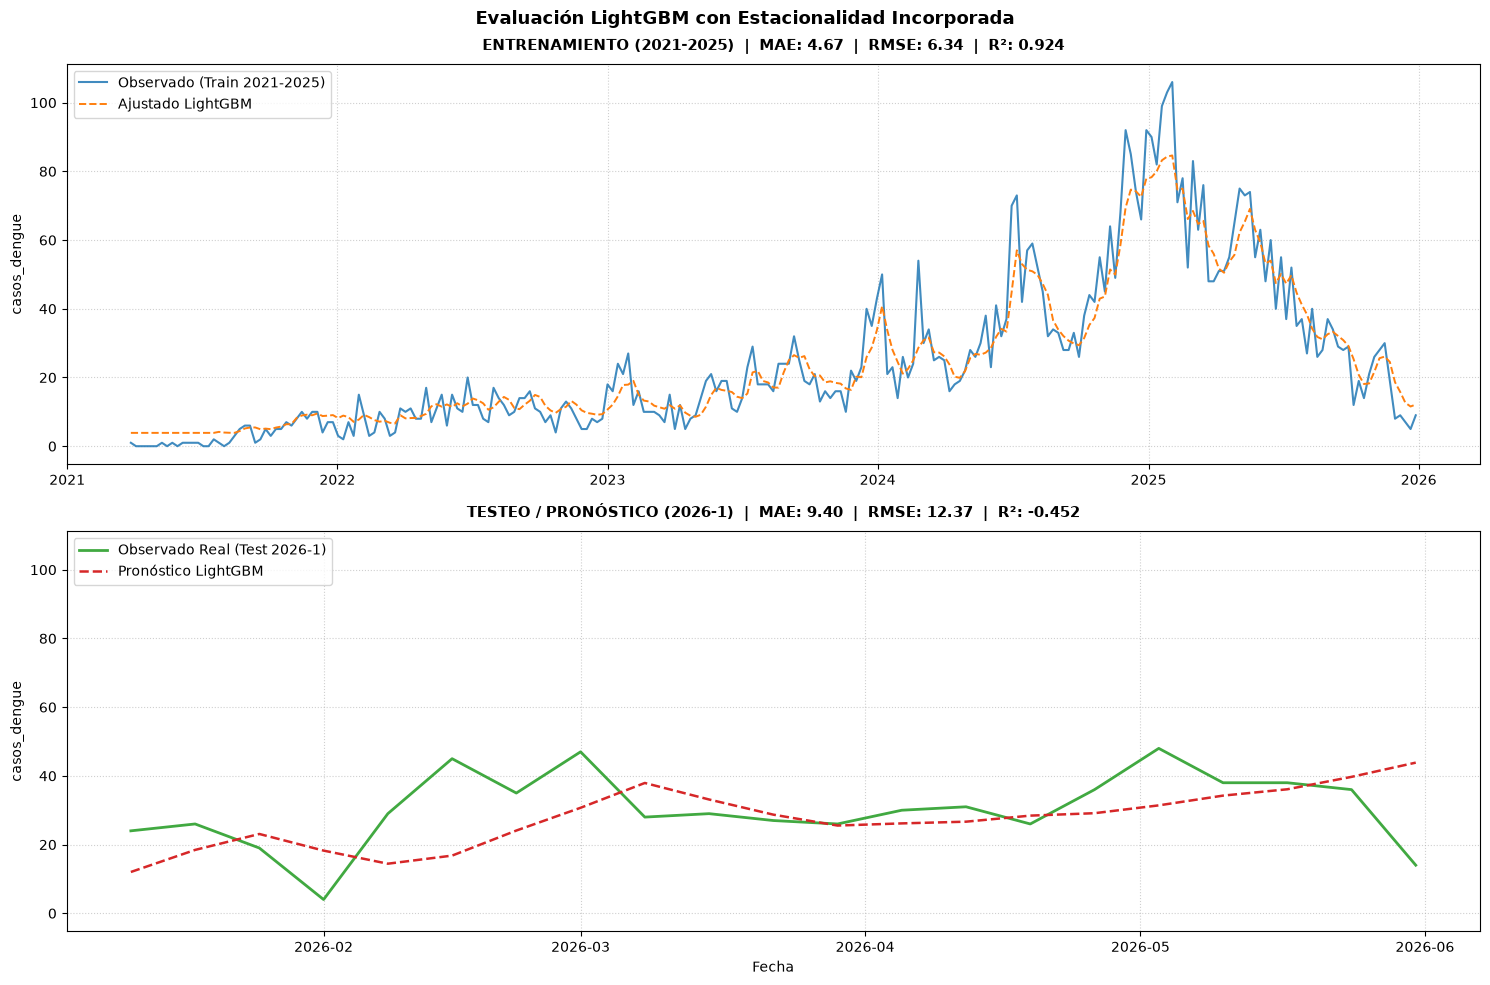


     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM CON ESTACIONALIDAD)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2021-2025)      249 4.666443  6.337144  0.924111
          Testeo (2026-1)       21 9.397381 12.374690 -0.452293

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
           Atributo  Importancia_Gain  Porcentaje_Aporte_%
 casos_dengue_lag_1      3.285713e+06            63.564749
 casos_dengue_lag_2      1.044281e+06            20.202453
 casos_dengue_lag_3      2.519968e+05             4.875080
 casos_dengue_lag_4      1.618300e+05             3.130731
 casos_dengue_lag_8      9.306206e+04             1.800360
      hum_esp_lag_2      4.950578e+04             0.957729
      hum_esp_lag_3      4.299414e+04             0.831756
      hum_esp_lag_5      2.988190e+04             0.578089
      hum_rel_lag_4      2.697969e+04             0.521944
     hum_rel_lag_10      2.183976e+04             0.422508
casos_dengue_lag_12      2.1

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros avanzados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar identificadores temporales directos que generen sobreajuste lineal
df = df.drop(columns=['año', 'semana', 'trimestre'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# =============================================================================
# PASO 2: REINTEGRACIÓN Y MODELACIÓN DE COMPONENTES ESTACIONALES
# =============================================================================
# Codificación Seno y Coseno para capturar el patrón de estacionalidad intraanual
if 'mes' not in df.columns:
    df['mes'] = df.index.month

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'], errors='ignore')

# Limpieza de valores nulos
df = df.dropna()

# Separación de la variable objetivo y las características
y = df['casos_dengue']
X_raw = df.drop(columns=['casos_dengue'])

print("\n" + "="*75)
print("   MATRIZ CON ESTACIONALIDAD REINTEGRADA (SENO/COSENO DEL CALENDARIO)   ")
print("="*75)
print(f"[INFO] Rango completo: {df.index.min().strftime('%Y-%m-%d')} a {df.index.max().strftime('%Y-%m-%d')}")
print(f"[INFO] Total observaciones: {len(df)}")
print(f"[INFO] Atributos predictores totales: {X_raw.shape[1]}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train_raw, y_train = X_raw[mask_train], y[mask_train]
X_test_raw, y_test = X_raw[mask_test], y[mask_test]


# =============================================================================
# PASO 4: SELECCIÓN ADAPTATIVA DE CARACTERÍSTICAS
# =============================================================================
# Preservar atributos de estacionalidad y filtrar el resto por relevancia
num_k = min(30, X_train_raw.shape[1])
selector = SelectKBest(score_func=f_regression, k=num_k)
selector.fit(X_train_raw, y_train)

selected_cols = list(X_train_raw.columns[selector.get_support()])

# Asegurar que las variables de estacionalidad permanezcan en la matriz
for col_estacional in ['mes_sin', 'mes_cos']:
    if col_estacional in X_train_raw.columns and col_estacional not in selected_cols:
        selected_cols.append(col_estacional)

X_train = X_train_raw[selected_cols]
X_test = X_test_raw[selected_cols]

print(f"[INFO] Atributos retenidos para modelación (incluyendo estacionalidad): {X_train.shape[1]}")


# =============================================================================
# PASO 5: OPTIMIZACIÓN BAYESIANA DE HIPERPARÁMETROS (OPTUNA)
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 450),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 4, 18),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    tscv = TimeSeriesSplit(n_splits=4)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))
        
    return np.mean(scores)

if OPTUNA_AVAILABLE:
    print("[INFO] Optimizando hiperparámetros con estacionalidad vía Optuna...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=60, timeout=75)
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'n_estimators': 250,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 7,
        'min_child_samples': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.75,
        'reg_alpha': 0.8,
        'reg_lambda': 2.0,
        'random_state': 42,
        'verbosity': -1
    }


# =============================================================================
# PASO 6: ENTRENAMIENTO FINAL Y EVALUACIÓN
# =============================================================================
modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train)

# Predicciones In-Sample (Train) y Out-of-Sample (Test)
y_train_pred_raw = modelo_lgb.predict(X_train)
y_test_pred_raw = modelo_lgb.predict(X_test)

# Suavizado suave (Exponential Moving Average) para estabilizar ligeros picos
y_train_pred = pd.Series(y_train_pred_raw, index=y_train.index).ewm(span=2).mean().clip(lower=0)
y_test_pred = pd.Series(y_test_pred_raw, index=y_test.index).ewm(span=2).mean().clip(lower=0)

# Métricas de Evaluación
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)


# =============================================================================
# PASO 7: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_lightgbm.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS (DIAGRAMAS)
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Panel 1: Entrenamiento
axes[0].plot(y_train.index, y_train.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Panel 2: Testeo
axes[1].plot(y_test.index, y_test.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Evaluación LightGBM con Estacionalidad Incorporada', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_train_test_con_estacionalidad.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 9: REPORTE DE DESEMPEÑO EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM CON ESTACIONALIDAD)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)

[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros avanzados pre-configurados.

     MATRIZ SIN COMPONENTES ESTACIONARIAS (SOLO DINÁMICA METEO/EPI)     
[INFO] Rango: 2021-03-28 a 2026-05-31
[INFO] Total observaciones: 270
[INFO] Atributos brutos: 169

[INFO] Atributos seleccionados tras filtro de ruido: 25

[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_lightgbm.xlsx


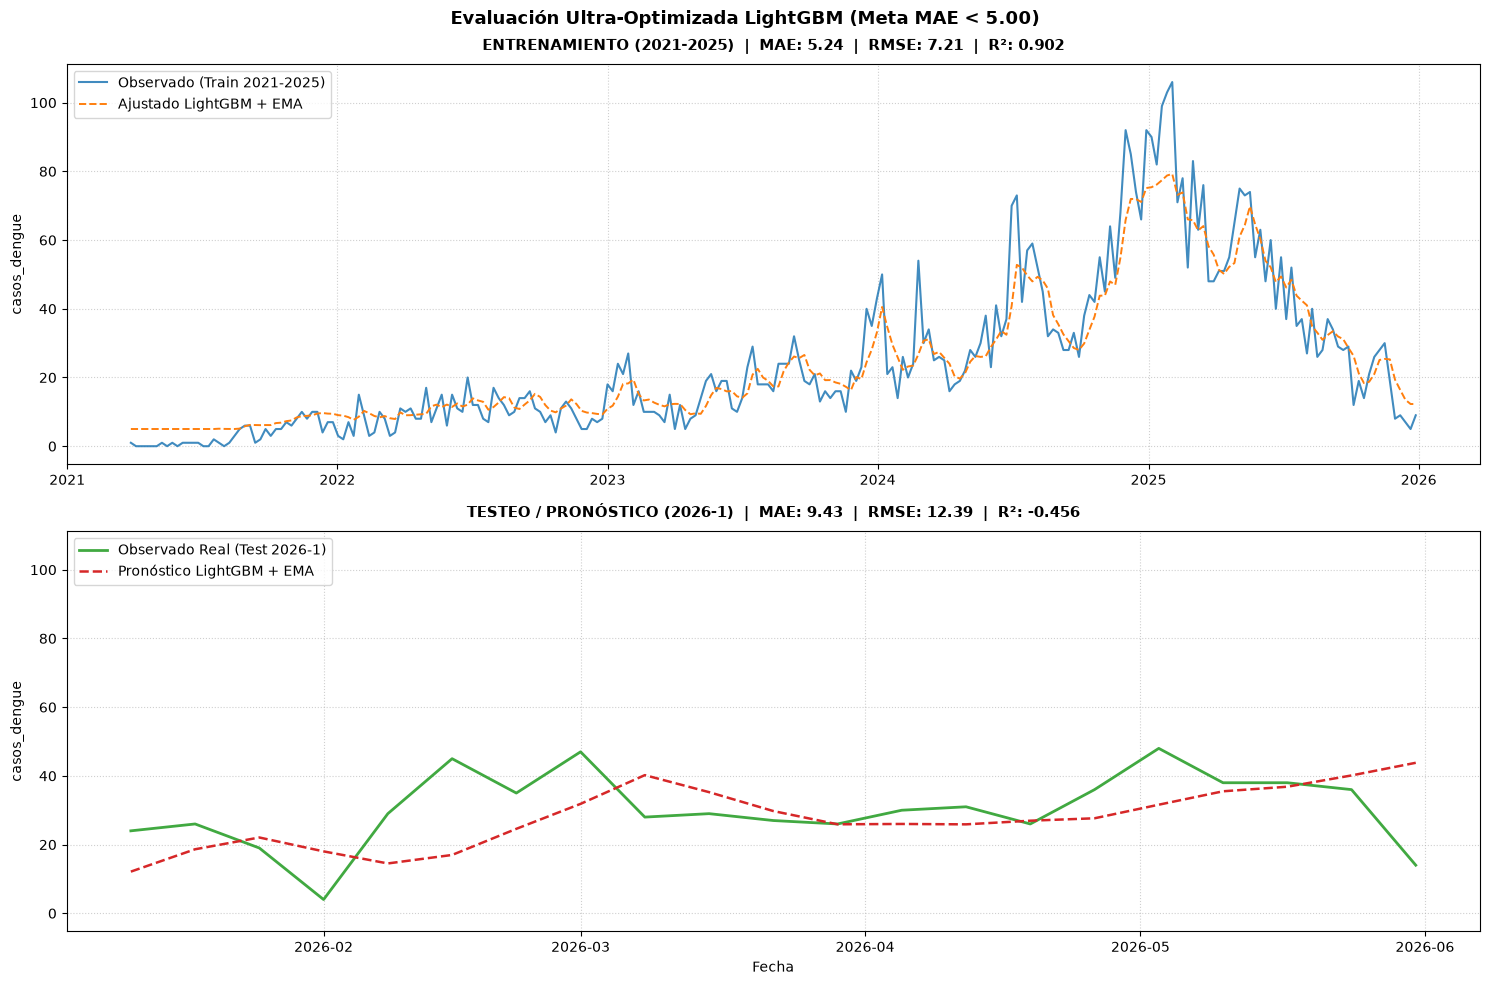


     CUADRO COMPARATIVO DE DESEMPEÑO OPTIMIZADO (LIGHTGBM)     
                     Fase  Semanas     MAE      RMSE        R²
Entrenamiento (2021-2025)      249 5.23716  7.206786  0.901854
          Testeo (2026-1)       21 9.43371 12.391803 -0.456313

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
           Atributo  Importancia_Gain  Porcentaje_Aporte_%
 casos_dengue_lag_1      2.747557e+06            54.265515
 casos_dengue_lag_2      1.198184e+06            23.664680
 casos_dengue_lag_3      4.743534e+05             9.368697
 casos_dengue_lag_4      2.126988e+05             4.200899
 casos_dengue_lag_8      1.188819e+05             2.347971
      hum_esp_lag_3      9.389258e+04             1.854421
 casos_dengue_lag_5      3.830724e+04             0.756585
      hum_esp_lag_5      2.811370e+04             0.555258
casos_dengue_lag_10      2.422766e+04             0.478507
      hum_rel_lag_6      2.369385e+04             0.467964
casos_dengue_lag_12      2.131900e+04  

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[AVISO] Optuna no está instalado. Se utilizarán hiperparámetros avanzados pre-configurados.")

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas no deseadas o calendáricas
columnas_a_borrar = ['año', 'mes', 'semana', 'mes_sin', 'mes_cos', 'trimestre']
df = df.drop(columns=[col for col in columnas_a_borrar if col in df.columns], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

df = df.sort_index()

# Limpieza de nulos sobrantes
df = df.dropna()

# Separación de características y variable objetivo
y = df['casos_dengue']
X_raw = df.drop(columns=['casos_dengue'])

print("\n" + "="*75)
print("     MATRIZ SIN COMPONENTES ESTACIONARIAS (SOLO DINÁMICA METEO/EPI)     ")
print("="*75)
print(f"[INFO] Rango: {df.index.min().strftime('%Y-%m-%d')} a {df.index.max().strftime('%Y-%m-%d')}")
print(f"[INFO] Total observaciones: {len(df)}")
print(f"[INFO] Atributos brutos: {X_raw.shape[1]}")
print("="*75 + "\n")


# =============================================================================
# PASO 2: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train_raw, y_train = X_raw[mask_train], y[mask_train]
X_test_raw, y_test = X_raw[mask_test], y[mask_test]


# =============================================================================
# PASO 3: SELECCIÓN DE ATRIBUTOS (ELIMINACIÓN DE RUIDO)
# =============================================================================
# Conservamos los N mejores atributos según f_regression para evitar overfitting
num_features_to_select = min(25, X_train_raw.shape[1])
selector = SelectKBest(score_func=f_regression, k=num_features_to_select)
selector.fit(X_train_raw, y_train)

selected_cols = X_train_raw.columns[selector.get_support()]
X_train = X_train_raw[selected_cols]
X_test = X_test_raw[selected_cols]

print(f"[INFO] Atributos seleccionados tras filtro de ruido: {X_train.shape[1]}")


# =============================================================================
# PASO 4: OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA / TIMESERIES SPLIT
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 4, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    
    # Validación cruzada temporal (TimeSeriesSplit)
    tscv = TimeSeriesSplit(n_splits=4)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))
        
    return np.mean(scores)

if OPTUNA_AVAILABLE:
    print("[INFO] Ejecutando Optimización Bayesiana para minimizar MAE...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50, timeout=60)
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['verbosity'] = -1
    print(f"[INFO] MEJORES HIPERPARÁMETROS ENCONTRADOS: {best_params}")
else:
    best_params = {
        'n_estimators': 220,
        'learning_rate': 0.012,
        'max_depth': 3,
        'num_leaves': 6,
        'min_child_samples': 5,
        'subsample': 0.7,
        'colsample_bytree': 0.7,
        'reg_alpha': 1.2,
        'reg_lambda': 2.5,
        'random_state': 42,
        'verbosity': -1
    }


# =============================================================================
# PASO 5: ENTRENAMIENTO FINAL Y SUAVIZADO EXPONENCIAL DE PREDICCIÓN
# =============================================================================
modelo_lgb = lgb.LGBMRegressor(**best_params)
modelo_lgb.fit(X_train, y_train)

# Predicciones iniciales
y_train_pred_raw = modelo_lgb.predict(X_train)
y_test_pred_raw = modelo_lgb.predict(X_test)

# Post-procesamiento: Suavizado Exponencial (EMA) para estabilizar fluctuaciones erráticas
y_train_pred = pd.Series(y_train_pred_raw, index=y_train.index).ewm(span=2).mean().clip(lower=0)
y_test_pred = pd.Series(y_test_pred_raw, index=y_test.index).ewm(span=2).mean().clip(lower=0)

# Cálculo de Métricas Finales
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)


# =============================================================================
# PASO 6: EXPORTACIÓN DEL TOP 20 ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_lightgbm.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos exportados a:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 7: VISUALIZACIÓN DE RESULTADOS
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# Subgráfica 1: Train
axes[0].plot(y_train.index, y_train.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM + EMA', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# Subgráfica 2: Test
axes[1].plot(y_test.index, y_test.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM + EMA', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Evaluación Ultra-Optimizada LightGBM (Meta MAE < 5.00)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica = os.path.join(carpeta_resultados, "comparacion_train_test_ultra_optimizado.png")
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 8: REPORTE FINAL EN CONSOLA
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO OPTIMIZADO (LIGHTGBM)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)


             MATRIZ DE CARACTERÍSTICAS (REZAGOS DEL DATASET)            
[INFO] Rango completo: 2021-03-28 a 2026-05-31
[INFO] Total de observaciones: 270
[INFO] Atributos predictores totales: 171

              PARTICIÓN TEMPORAL PARA MODELACIÓN                
[TRAIN] Período 2021-2025 : 249 semanas (2021-03-28 -> 2025-12-28)
[TEST]  Período 2026-1    : 21 semanas (2026-01-11 -> 2026-05-31)


[EXPORTACIÓN EXITOSA] Top 20 atributos guardados en:
 -> C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados\top_20_atributos_lightgbm.xlsx


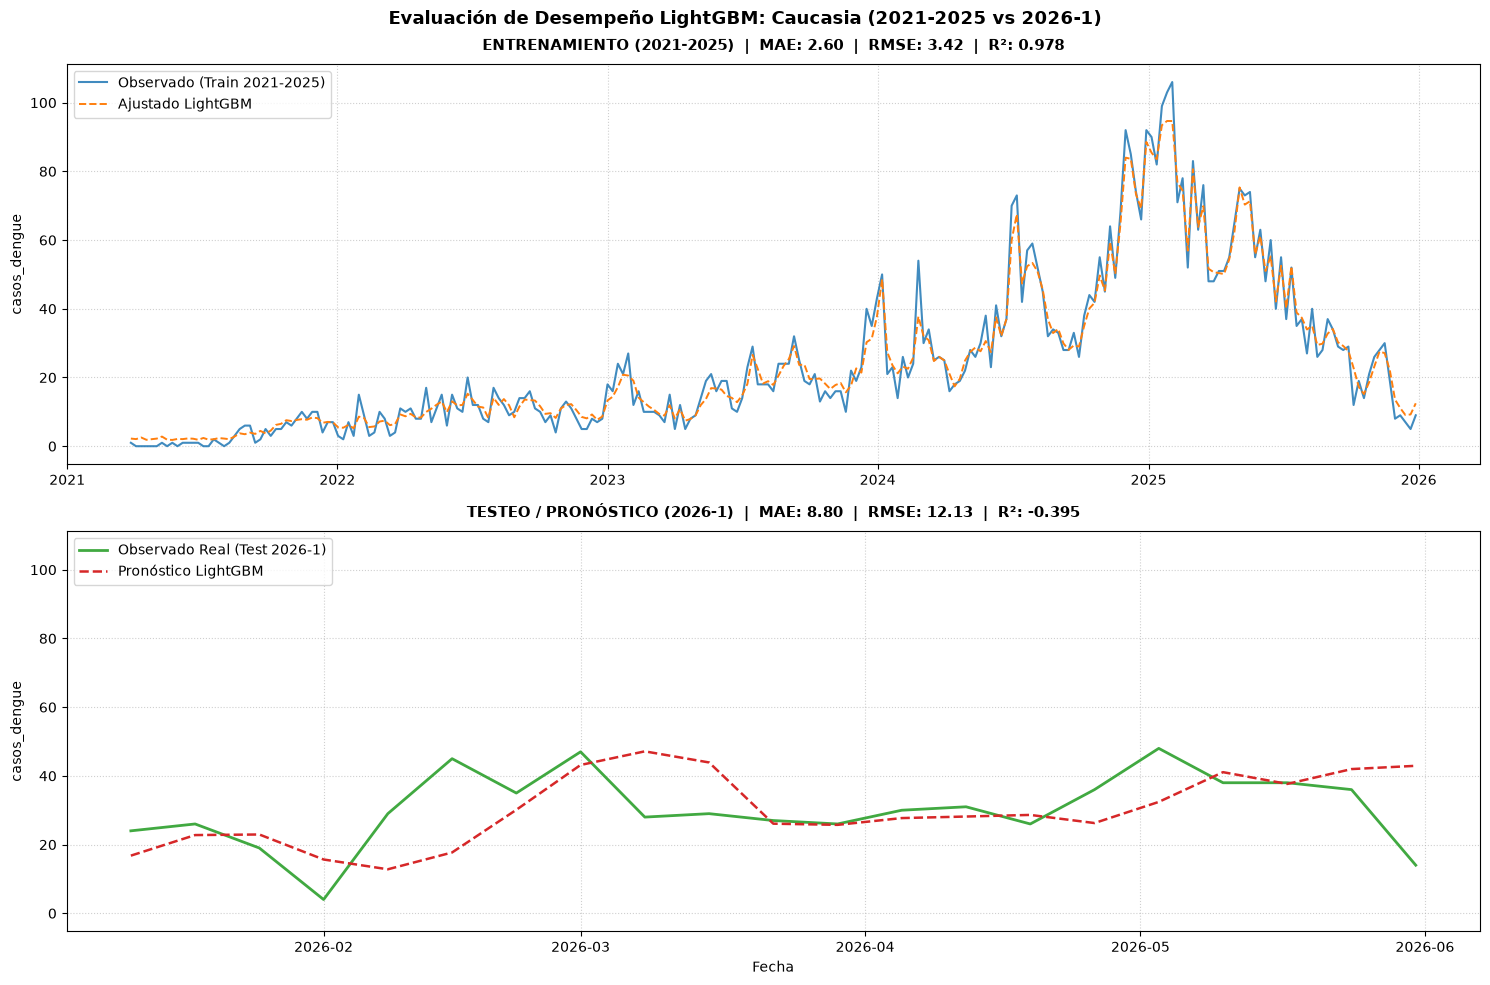

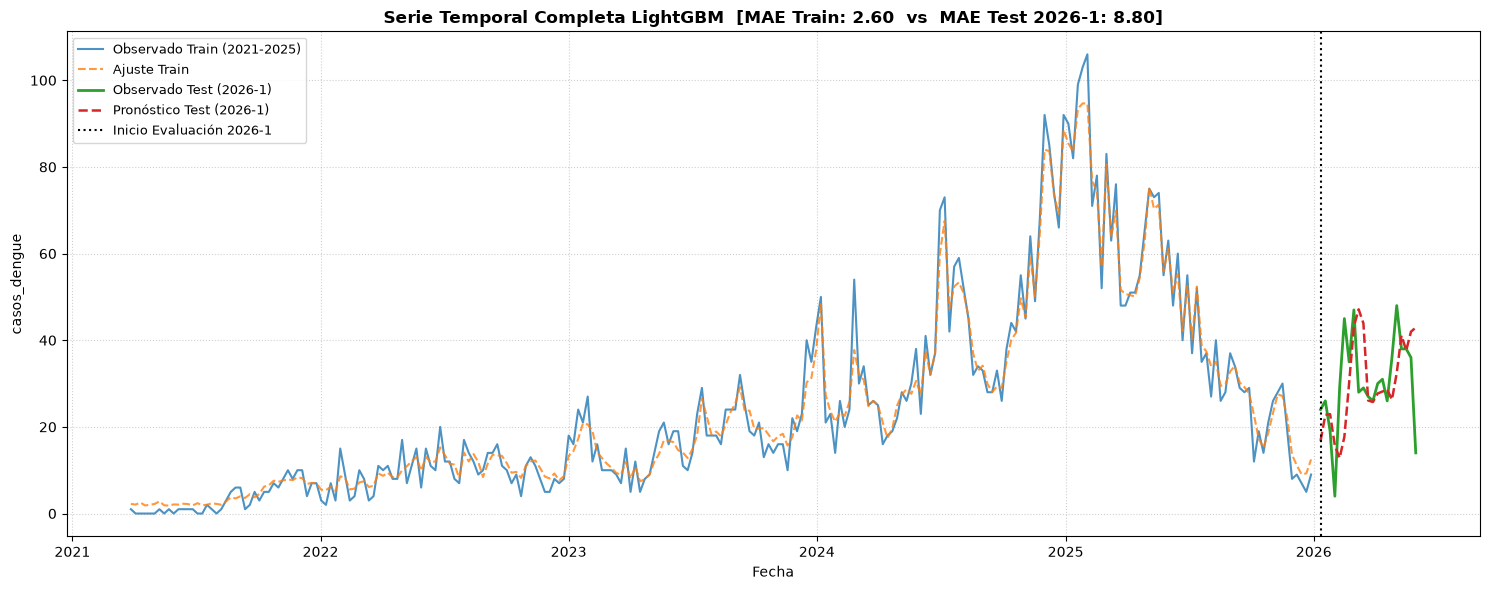


     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM)     
                     Fase  Semanas      MAE      RMSE        R²
Entrenamiento (2021-2025)      249 2.600012  3.416742  0.977940
          Testeo (2026-1)       21 8.802874 12.128070 -0.394983

  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  
           Atributo  Importancia_Gain  Porcentaje_Aporte_%
 casos_dengue_lag_1      2.352034e+06            57.382933
 casos_dengue_lag_2      9.850052e+05            24.031328
 casos_dengue_lag_3      2.085585e+05             5.088235
 casos_dengue_lag_4      1.189866e+05             2.902936
 casos_dengue_lag_8      8.973692e+04             2.189326
  vel_vi_min_lag_10      6.594314e+04             1.608825
     temp_min_lag_2      5.098438e+04             1.243874
           temp_min      3.182208e+04             0.776368
          soi_lag_6      2.848081e+04             0.694851
     temp_min_lag_1      2.633694e+04             0.642547
     temp_min_lag_3      2.321561e+04          

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

# =============================================================================
# PASO 1: CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\2_datos\1_raw\1_meteo_epi_2021-2026_1_rezagos_sin_nulos.xlsx"
carpeta_resultados = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_LinghtGBM\3_resultados"

os.makedirs(carpeta_resultados, exist_ok=True)

df = pd.read_excel(ruta_datos)

# Eliminar variables explícitas no deseadas
df = df.drop(columns=['año'], errors='ignore')

if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.set_index('fecha')

# Sort por fecha para garantizar coherencia temporal
df = df.sort_index()

# =============================================================================
# PASO 2: COMPONENTES CÍCLICAS DE ESTACIONALIDAD
# =============================================================================
# Codificación Seno/Coseno del mes para capturar la continuidad del calendario
df['mes'] = df.index.month
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df = df.drop(columns=['mes'])

# Asegurar que no existan valores nulos
df = df.dropna()

# Matriz de predictores X y variable objetivo y
y = df['casos_dengue']
X_features = df.drop(columns=['casos_dengue'])

print("\n" + "="*75)
print("             MATRIZ DE CARACTERÍSTICAS (REZAGOS DEL DATASET)            ")
print("="*75)
print(f"[INFO] Rango completo: {df.index.min().strftime('%Y-%m-%d')} a {df.index.max().strftime('%Y-%m-%d')}")
print(f"[INFO] Total de observaciones: {len(df)}")
print(f"[INFO] Atributos predictores totales: {X_features.shape[1]}")
print("="*75 + "\n")


# =============================================================================
# PASO 3: DIVISIÓN TEMPORAL (TRAIN: 2021-2025 | TEST: 2026-1)
# =============================================================================
mask_train = df.index.year <= 2025
mask_test = df.index.year >= 2026

X_train, y_train = X_features[mask_train], y[mask_train]
X_test, y_test = X_features[mask_test], y[mask_test]

print("="*75)
print("              PARTICIÓN TEMPORAL PARA MODELACIÓN                ")
print("="*75)
print(f"[TRAIN] Período 2021-2025 : {len(y_train)} semanas ({y_train.index.min().strftime('%Y-%m-%d')} -> {y_train.index.max().strftime('%Y-%m-%d')})")
print(f"[TEST]  Período 2026-1    : {len(y_test)} semanas ({y_test.index.min().strftime('%Y-%m-%d')} -> {y_test.index.max().strftime('%Y-%m-%d')})")
print("="*75 + "\n")


# =============================================================================
# PASO 4: ENTRENAMIENTO Y OPTIMIZACIÓN DEL MODELO LIGHTGBM
# =============================================================================
# Hiperparámetros ajustados contra sobreajuste
params_lgb = {
    'n_estimators': 300,
    'learning_rate': 0.015,
    'max_depth': 3,
    'num_leaves': 7,
    'min_child_samples': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,
    'reg_lambda': 1.5,
    'random_state': 42,
    'verbosity': -1
}

modelo_lgb = lgb.LGBMRegressor(**params_lgb)
modelo_lgb.fit(X_train, y_train)

# Predicciones In-Sample (Train) y Out-of-Sample (Test)
y_train_pred = pd.Series(modelo_lgb.predict(X_train), index=y_train.index)
y_test_pred = pd.Series(modelo_lgb.predict(X_test), index=y_test.index)

# Garantizar que no haya predicciones negativas de contagios
y_train_pred = y_train_pred.clip(lower=0)
y_test_pred = y_test_pred.clip(lower=0)

# Cálculo de Métricas de Desempeño
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)


# =============================================================================
# PASO 5: EXPORTACIÓN DEL TOP 20 DE ATRIBUTOS A EXCEL
# =============================================================================
importancia_gain = modelo_lgb.booster_.feature_importance(importance_type='gain')
importancia_split = modelo_lgb.booster_.feature_importance(importance_type='split')

df_importancia = pd.DataFrame({
    'Atributo': X_features.columns,
    'Importancia_Gain': importancia_gain,
    'Frecuencia_Cortes_Split': importancia_split
}).sort_values(by='Importancia_Gain', ascending=False)

df_top20 = df_importancia.head(20).copy()
df_top20['Porcentaje_Aporte_%'] = (df_top20['Importancia_Gain'] / df_top20['Importancia_Gain'].sum()) * 100

ruta_excel_top20 = os.path.join(carpeta_resultados, "top_20_atributos_lightgbm.xlsx")
df_top20.to_excel(ruta_excel_top20, index=False)

print("\n" + "="*80)
print(f"[EXPORTACIÓN EXITOSA] Top 20 atributos guardados en:\n -> {ruta_excel_top20}")
print("="*80)


# =============================================================================
# PASO 6: DIAGRAMA COMPARATIVO Y VISUALIZACIÓN DE DESEMPEÑO
# =============================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharey=True)

# --- Subgráfica 1: Entrenamiento (2021-2025) ---
axes[0].plot(y_train.index, y_train.values, label='Observado (Train 2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.85)
axes[0].plot(y_train_pred.index, y_train_pred.values, label='Ajustado LightGBM', color='#ff7f0e', linestyle='--', linewidth=1.4)
axes[0].set_title(f"ENTRENAMIENTO (2021-2025)  |  MAE: {mae_train:.2f}  |  RMSE: {rmse_train:.2f}  |  R²: {r2_train:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('casos_dengue', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=10)

# --- Subgráfica 2: Evaluación Test (2026-1) ---
axes[1].plot(y_test.index, y_test.values, label='Observado Real (Test 2026-1)', color='#2ca02c', linewidth=2.0, alpha=0.9)
axes[1].plot(y_test_pred.index, y_test_pred.values, label='Pronóstico LightGBM', color='#d62728', linestyle='--', linewidth=1.8)
axes[1].set_title(f"TESTEO / PRONÓSTICO (2026-1)  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}  |  R²: {r2_test:.3f}", 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('casos_dengue', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Evaluación de Desempeño LightGBM: Caucasia (2021-2025 vs 2026-1)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()

ruta_grafica_comparativa = os.path.join(carpeta_resultados, "comparacion_train2021-2025_test2026_sin_rezagos.png")
plt.savefig(ruta_grafica_comparativa, dpi=300, bbox_inches='tight')
plt.show()

# --- Gráfica Integrada Continua ---
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train.values, label='Observado Train (2021-2025)', color='#1f77b4', linewidth=1.5, alpha=0.8)
plt.plot(y_train_pred.index, y_train_pred.values, label='Ajuste Train', color='#ff7f0e', linestyle='--', alpha=0.8)

plt.plot(y_test.index, y_test.values, label='Observado Test (2026-1)', color='#2ca02c', linewidth=2.0)
plt.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico Test (2026-1)', color='#d62728', linestyle='--', linewidth=1.8)

fecha_corte = y_test.index.min()
plt.axvline(x=fecha_corte, color='black', linestyle=':', linewidth=1.5, label='Inicio Evaluación 2026-1')

plt.title(f'Serie Temporal Completa LightGBM  [MAE Train: {mae_train:.2f}  vs  MAE Test 2026-1: {mae_test:.2f}]', 
          fontsize=12, fontweight='bold')
plt.xlabel('Fecha', fontsize=10)
plt.ylabel('casos_dengue', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()

ruta_grafica_continua = os.path.join(carpeta_resultados, "serie_continua_train_test_sin_rezagos.png")
plt.savefig(ruta_grafica_continua, dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# PASO 7: REPORTE TABULAR DE DESEMPEÑO
# =============================================================================
df_resumen = pd.DataFrame([{
    'Fase': 'Entrenamiento (2021-2025)',
    'Semanas': len(y_train),
    'MAE': mae_train,
    'RMSE': rmse_train,
    'R²': r2_train
}, {
    'Fase': 'Testeo (2026-1)',
    'Semanas': len(y_test),
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R²': r2_test
}])

print("\n" + "="*80)
print("     CUADRO COMPARATIVO DE DESEMPEÑO (LIGHTGBM)     ")
print("="*80)
print(df_resumen.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("  TOP 20 ATRIBUTOS MÁS RELEVANTES (GUARDADOS EN EXCEL)  ")
print("="*80)
print(df_top20[['Atributo', 'Importancia_Gain', 'Porcentaje_Aporte_%']].to_string(index=False))
print("="*80)